# ET0737 Machine Learning & AI — Mini Project
## Diabetes Risk Prediction from the CDC BRFSS 2015 Health Survey

**School of EEE, Singapore Polytechnic — AY26/27 S1**

**Dataset:** CDC *Behavioral Risk Factor Surveillance System (BRFSS) 2015*
— 441,456 US adults surveyed by telephone.
Source (raw): https://www.cdc.gov/brfss/annual_data/annual_2015.html
· Kaggle mirror: https://www.kaggle.com/datasets/cdc/behavioral-risk-factor-surveillance-system

We use `data/processed/diabetes_2015_clean.csv` — the tidy 240,731 × 34 table produced by
our companion notebook **`01_Diabetes_2015_Cleaning.ipynb`**.

---
### What this notebook does (the standard ML workflow)
1. **Load & understand** the cleaned data and *justify why each characteristic was kept*.
2. **Explore (EDA)** — class balance, distributions, and risk-factor relationships with Matplotlib/Seaborn.
3. **Preprocess** — feature engineering, one-hot encoding, scaling, and a leakage-safe **train / validation / test** split.
4. **Train** five algorithm families: Logistic Regression, Decision Tree, Random Forest, SVM, and a Neural Network (MLP), with **hyperparameter tuning**.
5. **Evaluate & compare** — Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrices, and an overfitting check.
6. **Predict** on new patients + an **interactive risk calculator** (ipywidgets).
7. **Business insights** and a **Responsible-GenAI** reflection.

> **Problem type:** binary **classification**.
> **Target `Diabetes`** = 1 if the respondent is *pre-diabetic or diabetic* (stage 1 or 2), else 0.
> This "at-risk screening" framing is the clinically useful question — *who should be
> referred for a blood-glucose test?* — and it is the standard framing for this dataset.

## 1 · Setup & Load the Cleaned Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Parallelism budget: this machine has 8 cores but limited free RAM. We parallelise at
# exactly ONE level -- the cross-validation search -- and keep every estimator
# single-threaded (n_jobs=1). This avoids nested worker pools that would each copy the
# 144k-row training set and exhaust memory (the classic "kernel died" failure).
N_JOBS = 4

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
print("Libraries loaded. scikit-learn is the core ML toolkit for this project.")
print(f"Parallelism capped at N_JOBS={N_JOBS} (one level only) to stay within RAM.")

Libraries loaded. scikit-learn is the core ML toolkit for this project.
Parallelism capped at N_JOBS=4 (one level only) to stay within RAM.


In [2]:
df = pd.read_csv("../data/processed/diabetes_2015_clean.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 240,184 rows x 34 columns


,DiabetesStage,HighBP,HighChol,CholCheck,BMI,BMICategory,Smoker,SmokerStatus,Stroke,HeartDiseaseorAttack,...,DiffWalk,Sex,Age,AgeYears,Race,MaritalStatus,Education,Income,Employment,CheckupTime
0,0,1,1,1,40.18,4,1,1,0,0,...,1,0,9,63,1,1,4,3,8,1
1,0,0,0,0,25.09,3,1,3,0,0,...,0,0,7,52,1,2,6,1,3,4
2,0,1,1,1,28.19,3,0,0,0,0,...,1,0,9,63,1,1,4,8,8,1
3,0,1,0,1,26.52,3,0,0,0,0,...,0,0,11,73,1,3,3,6,2,1
4,0,1,1,1,23.89,2,0,0,0,0,...,0,0,11,70,7,3,5,4,7,1


In [3]:
# Structure + basic statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240184 entries, 0 to 240183
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   DiabetesStage         240184 non-null  int64  
 1   HighBP                240184 non-null  int64  
 2   HighChol              240184 non-null  int64  
 3   CholCheck             240184 non-null  int64  
 4   BMI                   240184 non-null  float64
 5   BMICategory           240184 non-null  int64  
 6   Smoker                240184 non-null  int64  
 7   SmokerStatus          240184 non-null  int64  
 8   Stroke                240184 non-null  int64  
 9   HeartDiseaseorAttack  240184 non-null  int64  
 10  KidneyDisease         240184 non-null  int64  
 11  COPD                  240184 non-null  int64  
 12  Arthritis             240184 non-null  int64  
 13  Depression            240184 non-null  int64  
 14  PhysActivity          240184 non-null  int64  
 15  

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
DiabetesStage,240184.0,0.29,0.70,0.00,0.00,0.00,0.00,2.00
HighBP,240184.0,0.43,0.49,0.00,0.00,0.00,1.00,1.00
HighChol,240184.0,0.42,0.49,0.00,0.00,0.00,1.00,1.00
CholCheck,240184.0,0.96,0.19,0.00,1.00,1.00,1.00,1.00
BMI,240184.0,28.28,6.10,12.02,24.14,27.34,31.25,69.94
BMICategory,240184.0,2.99,0.81,1.00,2.00,3.00,4.00,4.00
Smoker,240184.0,0.44,0.50,0.00,0.00,0.00,1.00,1.00
SmokerStatus,240184.0,0.67,0.93,0.00,0.00,0.00,1.00,3.00
Stroke,240184.0,0.04,0.20,0.00,0.00,0.00,0.00,1.00
HeartDiseaseorAttack,240184.0,0.09,0.29,0.00,0.00,0.00,0.00,1.00


## 2 · Why We Kept These Characteristics (Feature Justification)

The raw BRFSS survey has **330 columns**. Our cleaning notebook deliberately kept only
**33 predictors + the target**. Every kept characteristic is an *established, medically
plausible correlate of type-2 diabetes* — this is **domain-driven feature selection**,
which beats blindly throwing 330 noisy survey codes at a model (that would invite
over-fitting and hurt interpretability). We reject variables that (a) are survey
admin/weighting fields, (b) belong to unrelated modules (cancer, HIV, caregiving), or
(c) would **leak the target** (e.g. *age at diabetes diagnosis*, *insulin use*, *blood-sugar
test result* — those are only recorded **because** the person already has diabetes).

| # | Feature | Type | Why it predicts diabetes |
|---|---------|------|--------------------------|
| 1 | **BMI** | continuous | Excess body fat is the single biggest modifiable driver of insulin resistance. |
| 2 | **AgeYears** | continuous | Risk rises steeply with age as β-cell function declines. |
| 3 | **HighBP** | binary | Hypertension clusters with diabetes in metabolic syndrome. |
| 4 | **HighChol / CholCheck** | binary | Dyslipidaemia co-occurs with insulin resistance. |
| 5 | **GenHlth** | ordinal 1–5 | Self-rated health is a strong general morbidity proxy. |
| 6 | **DiffWalk / PhysHlth / MentHlth** | mixed | Functional limitation & poor health-days track chronic disease burden. |
| 7 | **HeartDiseaseorAttack / Stroke / KidneyDisease / COPD / Arthritis** | binary | Comorbidities that share risk factors with (or result from) diabetes. |
| 8 | **Smoker / SmokerStatus** | binary/ordinal | Smoking raises type-2 diabetes risk. |
| 9 | **PhysActivity / PhysActivityLevel** | binary/ordinal | Inactivity worsens glucose control. |
| 10 | **Fruits / Veggies / HvyAlcoholConsump** | binary | Diet quality & heavy drinking affect metabolic risk. |
| 11 | **Sex** | binary | Prevalence differs by sex. |
| 12 | **Income / Education / Employment / MaritalStatus** | ordinal/nominal | Socio-economic status shapes diet, stress & healthcare access. |
| 13 | **AnyHealthcare / NoDocbcCost / CheckupTime** | binary/ordinal | Healthcare access affects diagnosis & management. |
| 14 | **Race** | nominal | Prevalence varies across ethnic groups (must be used carefully — see Responsible-AI note). |

**Redundancy we will remove in §4:** the dataset ships **four** near-duplicate pairs, each
a finer- and coarser-grained copy of the same signal: `BMI` vs `BMICategory` (band),
`AgeYears` vs `Age` (5-year band), `Smoker` (binary) vs `SmokerStatus` (ordinal), and
`PhysActivity` (binary) vs `PhysActivityLevel` (ordinal). Keeping both members of a pair is
multicollinear and adds no information, so we keep exactly one of each: the **continuous**
`BMI` / `AgeYears` (dropping the bands), and the **binary** `Smoker` / `PhysActivity`
(dropping the ordinal recodes). We keep the binaries rather than the ordinals because they
correlate at least as strongly with the target *and*, unlike an ordinal passed through
un-encoded, they impose no unverified linear spacing on the linear models — giving cleaner,
more stable logistic-regression coefficients.

In [5]:
# Data-quality gate: the cleaning notebook already dropped all Don't-know/Refused codes,
# so we confirm there are no missing values and no exact duplicate rows to worry about.
print("Missing values per column (should all be 0):")
print(df.isna().sum().sum(), "total missing cells")
print("Duplicate rows:", df.duplicated().sum())

Missing values per column (should all be 0):
0 total missing cells
Duplicate rows: 79


## 3 · Exploratory Data Analysis (EDA)

Before modelling we *look* at the data — the fastest way to catch imbalance, skew, and
whether the features actually relate to the target.

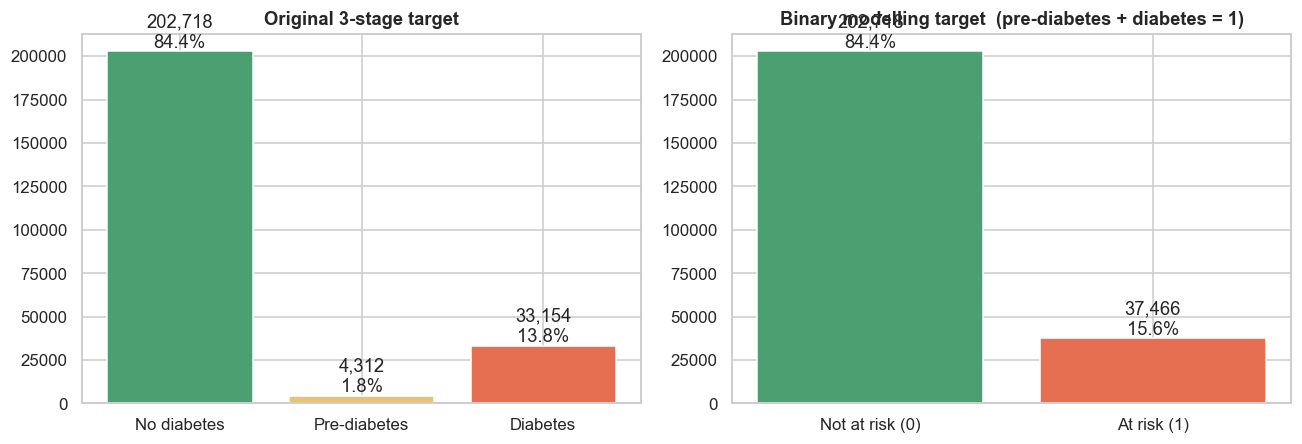

Positive (at-risk) rate: 15.6%  ->  this is an IMBALANCED problem.
=> Accuracy alone is misleading; we will emphasise Recall, F1 and ROC-AUC,
   and use class_weight='balanced' so the minority class is not ignored.


In [6]:
# --- Build the binary target: at-risk (pre-diabetes OR diabetes) = 1 ---
labels3 = {0: "No diabetes", 1: "Pre-diabetes", 2: "Diabetes"}
df["Diabetes"] = (df["DiabetesStage"] >= 1).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sc = df["DiabetesStage"].value_counts().sort_index()
ax[0].bar([labels3[i] for i in sc.index], sc.values, color=["#4C9F70", "#E9C46A", "#E76F51"])
ax[0].set_title("Original 3-stage target")
for i, v in enumerate(sc.values):
    ax[0].text(i, v, f"{v:,}\n{v/len(df):.1%}", ha="center", va="bottom")

bc = df["Diabetes"].value_counts().sort_index()
ax[1].bar(["Not at risk (0)", "At risk (1)"], bc.values, color=["#4C9F70", "#E76F51"])
ax[1].set_title("Binary modelling target  (pre-diabetes + diabetes = 1)")
for i, v in enumerate(bc.values):
    ax[1].text(i, v, f"{v:,}\n{v/len(df):.1%}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

print(f"Positive (at-risk) rate: {df['Diabetes'].mean():.1%}  ->  this is an IMBALANCED problem.")
print("=> Accuracy alone is misleading; we will emphasise Recall, F1 and ROC-AUC,")
print("   and use class_weight='balanced' so the minority class is not ignored.")

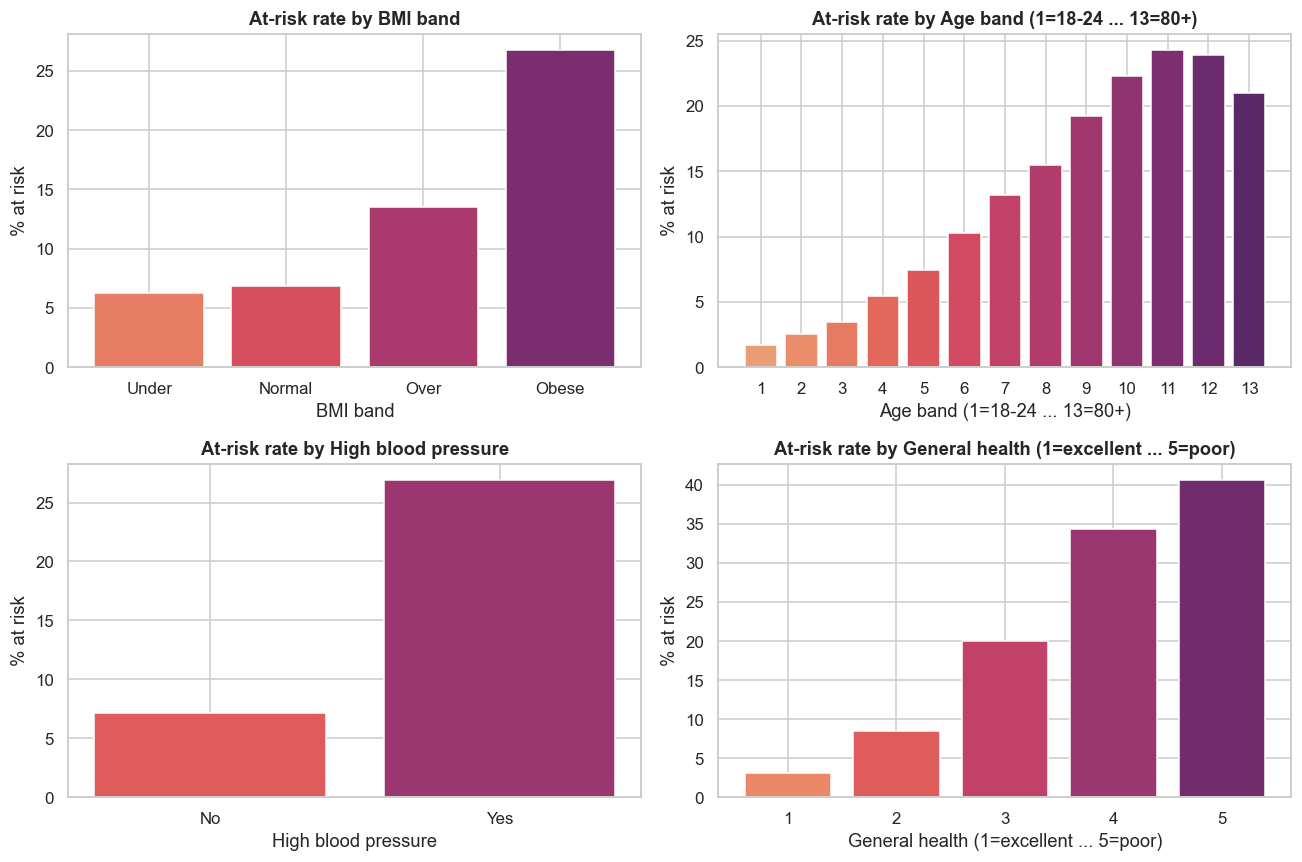

In [7]:
# Prevalence of diabetes/pre-diabetes across key risk factors — face-validity check
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
def prevalence_plot(ax, col, xlabel, xticklabels=None):
    p = df.groupby(col)["Diabetes"].mean() * 100
    ax.bar(p.index.astype(str), p.values, color=sns.color_palette("flare", len(p)))
    ax.set_title(f"At-risk rate by {xlabel}")
    ax.set_ylabel("% at risk"); ax.set_xlabel(xlabel)
    if xticklabels: ax.set_xticklabels(xticklabels, rotation=0)

prevalence_plot(axes[0,0], "BMICategory", "BMI band", ["Under", "Normal", "Over", "Obese"])
prevalence_plot(axes[0,1], "Age", "Age band (1=18-24 ... 13=80+)")
prevalence_plot(axes[1,0], "HighBP", "High blood pressure", ["No", "Yes"])
prevalence_plot(axes[1,1], "GenHlth", "General health (1=excellent ... 5=poor)")
plt.tight_layout(); plt.show()

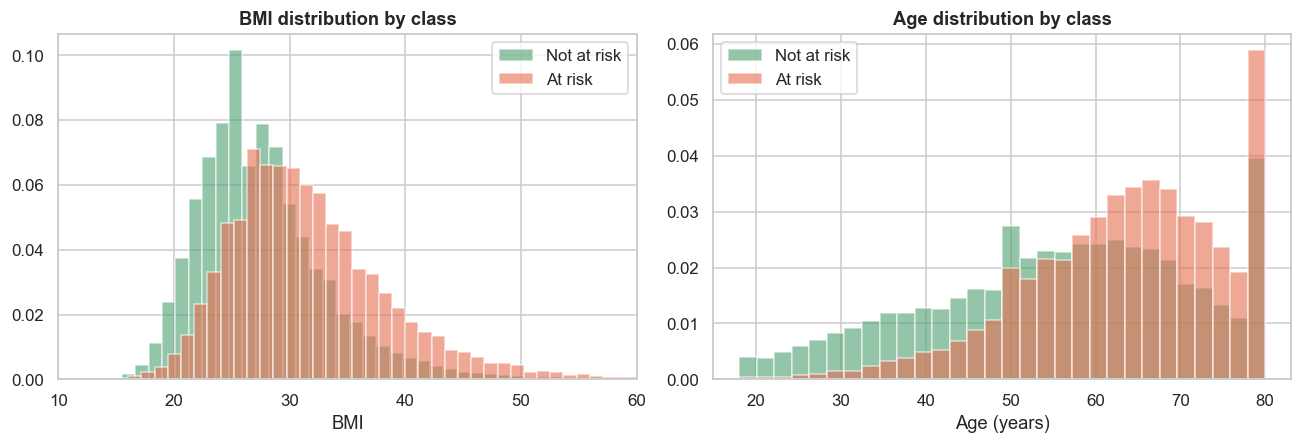

At-risk patients skew towards higher BMI and older age, exactly as clinical knowledge predicts.


In [8]:
# Distribution of the two key continuous features, split by class
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for cls, colr, lab in [(0, "#4C9F70", "Not at risk"), (1, "#E76F51", "At risk")]:
    sub = df[df["Diabetes"] == cls]
    ax[0].hist(sub["BMI"], bins=50, alpha=0.6, density=True, color=colr, label=lab)
    ax[1].hist(sub["AgeYears"], bins=30, alpha=0.6, density=True, color=colr, label=lab)
ax[0].set_title("BMI distribution by class"); ax[0].set_xlabel("BMI"); ax[0].set_xlim(10, 60); ax[0].legend()
ax[1].set_title("Age distribution by class"); ax[1].set_xlabel("Age (years)"); ax[1].legend()
plt.tight_layout(); plt.show()
print("At-risk patients skew towards higher BMI and older age, exactly as clinical knowledge predicts.")

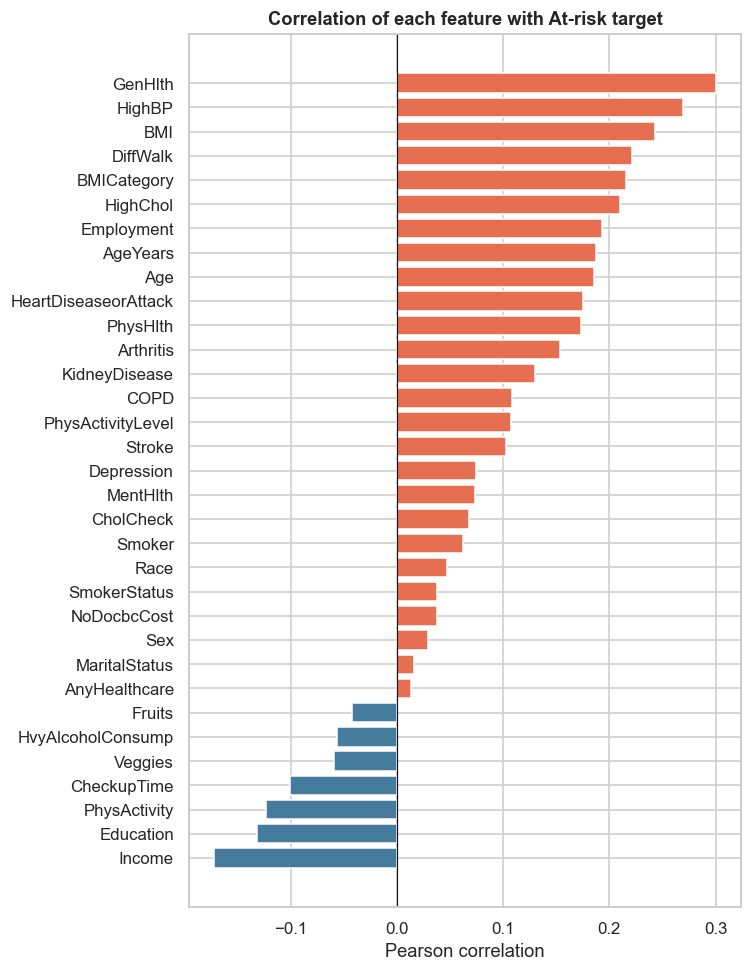

Strongest positive correlates: GenHlth, HighBP, BMI, DiffWalk, BMICategory


In [9]:
# Correlation of every feature with the target (point-biserial via Pearson on the binary target)
corr_target = df.drop(columns=["DiabetesStage"]).corr()["Diabetes"].drop("Diabetes").sort_values()
plt.figure(figsize=(7, 9))
colors = ["#E76F51" if v > 0 else "#457B9D" for v in corr_target.values]
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.title("Correlation of each feature with At-risk target")
plt.xlabel("Pearson correlation"); plt.axvline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()
print("Strongest positive correlates:", ", ".join(corr_target.tail(5).index[::-1]))

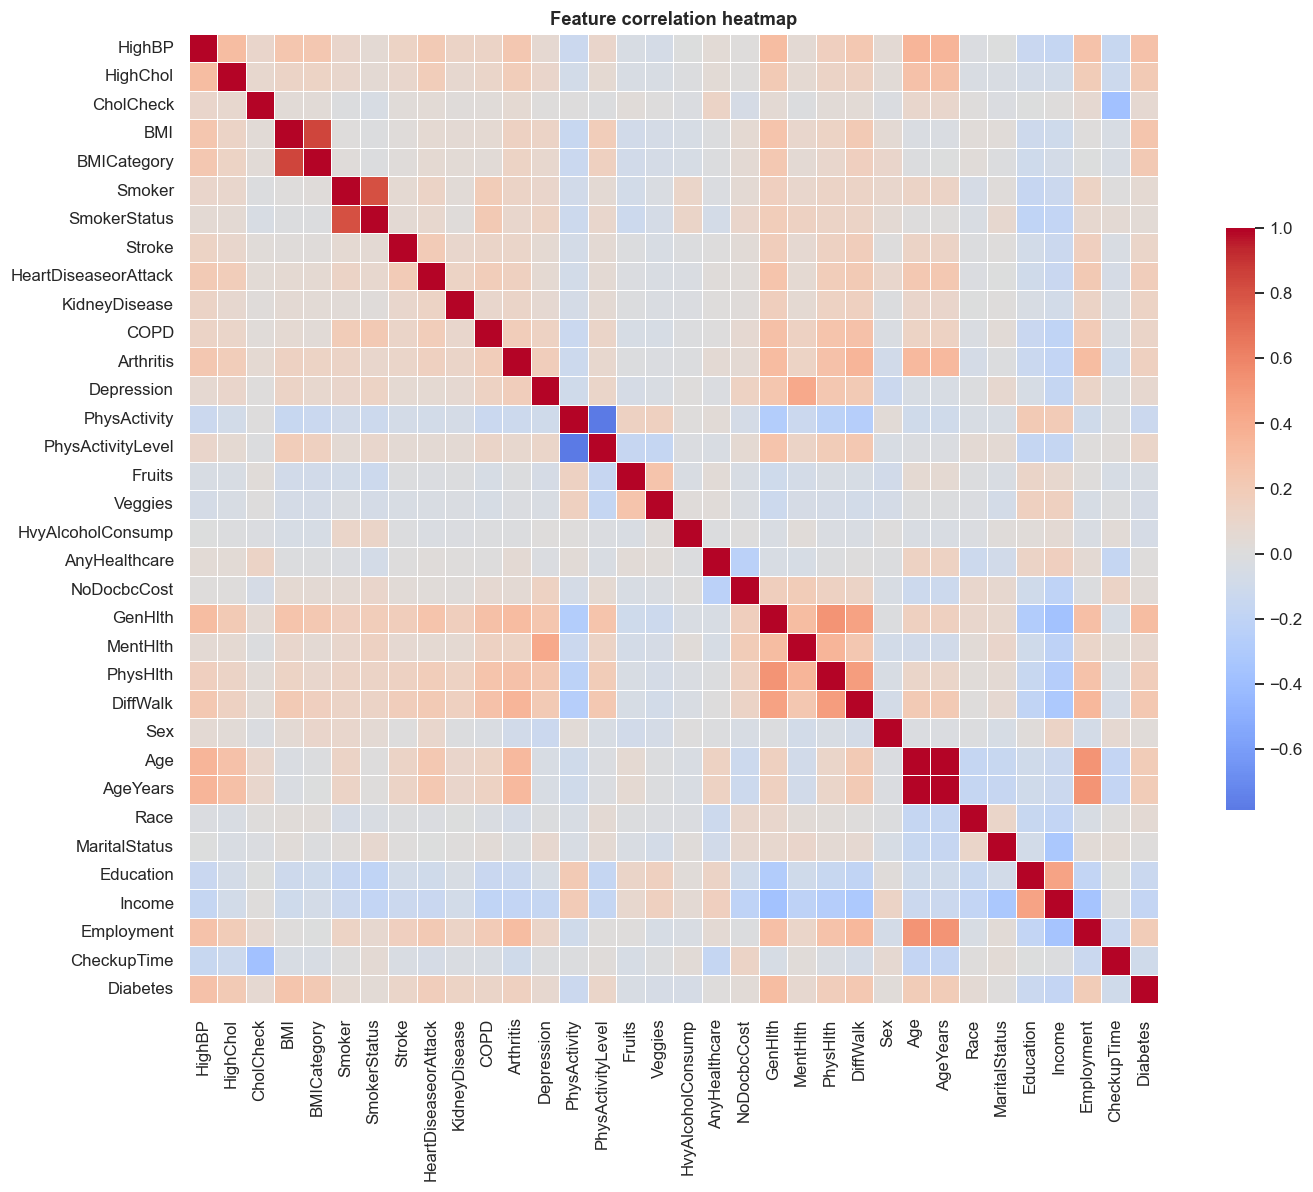

In [10]:
# Full correlation heatmap (spot multicollinearity). The dark off-diagonal blocks are the
# four near-duplicate pairs we deduplicate in §4: BMI/BMICategory, Age/AgeYears,
# Smoker/SmokerStatus, PhysActivity/PhysActivityLevel.
plt.figure(figsize=(14, 11))
sns.heatmap(df.drop(columns=["DiabetesStage"]).corr(), cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .6})
plt.title("Feature correlation heatmap")
plt.tight_layout(); plt.show()

## 4 · Preprocessing, Feature Engineering & Leakage-Safe Splitting

**Design choices (mapped to the rubric):**

* **Feature engineering / redundancy removal** — the survey ships four near-duplicate pairs
  (the dark blocks in the §3 heatmap). We keep one member of each and drop the other:
  drop the banded copies `Age` and `BMICategory` (lossy versions of continuous `AgeYears` /
  `BMI`), and drop the ordinal recodes `SmokerStatus` and `PhysActivityLevel`, keeping the
  binaries `Smoker` / `PhysActivity`. Keeping both members of a pair is multicollinear — it
  destabilises the logistic-regression coefficients and dilutes feature-importance scores.
  The binaries are kept over their ordinal twins because they correlate at least as strongly
  with the target and, passed through un-encoded, impose no unverified linear spacing.
* **Feature *types* drive the transform:**
  * *Continuous* (`BMI`, `AgeYears`, `MentHlth`, `PhysHlth`) → **StandardScaler**
    (required for the distance/gradient-based SVM & MLP; harmless for the others).
  * *Nominal / unordered* (`Race`, `MaritalStatus`, `Employment`) → **One-Hot Encoding**
    (their integer codes have no numeric order, so we must not let the model treat 3 > 2).
  * *Binary & ordinal* (HighBP, GenHlth, Income, …) → **passthrough** (already meaningful 0/1 or ranked integers).
* **Leakage prevention** — all transforms live **inside a `Pipeline`** and are `fit` on
  **training data only**. The scaler's mean/σ and the encoder's categories are learned
  from the train split, then merely *applied* to validation/test. We also split **before**
  any fitting.
* **Train / Validation / Test = 60 / 20 / 20**, *stratified* so the ~16 % positive rate
  is preserved in every split. Validation tunes/compares models; test is touched **once** at the end.

In [11]:
# Drop one member of each redundant near-duplicate pair (see §4 rationale + heatmap),
# plus the multiclass label; define X / y.
#   Age, BMICategory     -> banded copies of continuous AgeYears / BMI  (keep continuous)
#   SmokerStatus         -> ordinal recode of the Smoker binary         (keep binary)
#   PhysActivityLevel    -> ordinal recode of the PhysActivity binary   (keep binary)
X = df.drop(columns=["DiabetesStage", "Diabetes",
                     "Age", "BMICategory",
                     "SmokerStatus", "PhysActivityLevel"])
y = df["Diabetes"]

numeric_features = ["BMI", "AgeYears", "MentHlth", "PhysHlth"]
nominal_features = ["Race", "MaritalStatus", "Employment"]
passthrough_features = [c for c in X.columns if c not in numeric_features + nominal_features]

print(f"{X.shape[1]} predictors ->")
print(" scaled  :", numeric_features)
print(" one-hot :", nominal_features)
print(" as-is   :", passthrough_features)

29 predictors ->
 scaled  : ['BMI', 'AgeYears', 'MentHlth', 'PhysHlth']
 one-hot : ['Race', 'MaritalStatus', 'Employment']
 as-is   : ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'KidneyDisease', 'COPD', 'Arthritis', 'Depression', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Education', 'Income', 'CheckupTime']


In [12]:
# 60/20/20 stratified split (train -> then split temp into val/test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name:5s}: {len(yy):>7,} rows | positive rate {yy.mean():.1%}")

Train: 144,110 rows | positive rate 15.6%
Val  :  48,037 rows | positive rate 15.6%
Test :  48,037 rows | positive rate 15.6%


In [13]:
# One preprocessor, reused by every model pipeline -> guarantees identical, leakage-free prep
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), nominal_features),
    ("pass", "passthrough", passthrough_features),
])
print("Preprocessor built (StandardScaler + OneHotEncoder + passthrough).")

Preprocessor built (StandardScaler + OneHotEncoder + passthrough).


In [14]:
# Helper: compute the full metric suite for a fitted estimator on a given split
def evaluate(model, X_, y_, name, split):
    pred = model.predict(X_)
    proba = model.predict_proba(X_)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_)
    return {
        "Model": name, "Split": split,
        "Accuracy":  accuracy_score(y_, pred),
        "Precision": precision_score(y_, pred, zero_division=0),
        "Recall":    recall_score(y_, pred),
        "F1":        f1_score(y_, pred),
        "ROC-AUC":   roc_auc_score(y_, proba),
    }

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results = []          # collect val/test metric rows
fitted  = {}          # store the tuned best pipeline per model
print("Helper ready.")

Helper ready.


In [15]:
# ---------- 5.1 Logistic Regression (L1 vs L2 regularisation) ----------
lr_pipe = Pipeline([("prep", preprocessor),
                    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                               solver="liblinear", random_state=RANDOM_STATE))])
lr_grid = {"clf__C": [0.01, 0.1, 1, 10], "clf__penalty": ["l1", "l2"]}
lr_search = GridSearchCV(lr_pipe, lr_grid, scoring="roc_auc", cv=cv, n_jobs=N_JOBS)
lr_search.fit(X_train, y_train)
fitted["Logistic Regression"] = lr_search.best_estimator_
print("Best LR params:", lr_search.best_params_, "| CV AUC =", round(lr_search.best_score_, 4))
results.append(evaluate(lr_search.best_estimator_, X_train, y_train, "Logistic Regression", "Train"))
results.append(evaluate(lr_search.best_estimator_, X_val,   y_val,   "Logistic Regression", "Val"))

Best LR params: {'clf__C': 0.1, 'clf__penalty': 'l2'} | CV AUC = 0.8262


In [16]:
# ---------- 5.2 Decision Tree ----------
dt_pipe = Pipeline([("prep", preprocessor),
                    ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE))])
dt_grid = {"clf__max_depth": [4, 6, 8, 12], "clf__min_samples_leaf": [20, 50, 100]}
dt_search = GridSearchCV(dt_pipe, dt_grid, scoring="roc_auc", cv=cv, n_jobs=N_JOBS)
dt_search.fit(X_train, y_train)
fitted["Decision Tree"] = dt_search.best_estimator_
print("Best DT params:", dt_search.best_params_, "| CV AUC =", round(dt_search.best_score_, 4))
results.append(evaluate(dt_search.best_estimator_, X_train, y_train, "Decision Tree", "Train"))
results.append(evaluate(dt_search.best_estimator_, X_val,   y_val,   "Decision Tree", "Val"))

Best DT params: {'clf__max_depth': 8, 'clf__min_samples_leaf': 100} | CV AUC = 0.8116


In [17]:
# ---------- 5.3 Random Forest (RandomizedSearch to keep runtime sane) ----------
# NOTE ON MEMORY: the forest's own n_jobs=1. Parallelism happens only in the
# RandomizedSearchCV (n_jobs=N_JOBS). If we let BOTH parallelise we'd spawn nested
# worker pools, each copying the 144k-row training data -> out-of-memory / dead kernel.
# We also keep max_depth bounded (no None) -- this both caps memory and is the correct
# overfitting control for a forest on 240k noisy survey rows.
rf_pipe = Pipeline([("prep", preprocessor),
                    ("clf", RandomForestClassifier(class_weight="balanced_subsample",
                                                   random_state=RANDOM_STATE, n_jobs=1))])
rf_dist = {"clf__n_estimators": [150, 250, 350],
           "clf__max_depth": [10, 16, 22],
           "clf__min_samples_leaf": [5, 10, 20],
           "clf__max_features": ["sqrt", 0.5]}
rf_search = RandomizedSearchCV(rf_pipe, rf_dist, n_iter=8, scoring="roc_auc",
                               cv=cv, n_jobs=N_JOBS, random_state=RANDOM_STATE)
rf_search.fit(X_train, y_train)
fitted["Random Forest"] = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_, "| CV AUC =", round(rf_search.best_score_, 4))
results.append(evaluate(rf_search.best_estimator_, X_train, y_train, "Random Forest", "Train"))
results.append(evaluate(rf_search.best_estimator_, X_val,   y_val,   "Random Forest", "Val"))

Best RF params: {'clf__n_estimators': 350, 'clf__min_samples_leaf': 20, 'clf__max_features': 'sqrt', 'clf__max_depth': 22} | CV AUC = 0.8287


In [18]:
# ---------- 5.4 SVM (RBF) on a stratified 15k subsample ----------
# A full RBF-SVM is O(n^2) in the number of rows and impractical on 144k rows, so we tune
# on a representative *stratified* subsample (a standard, honest engineering trade-off we
# note in the write-up). A stratified split keeps the ~16% positive rate intact.
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=15000, stratify=y_train, random_state=RANDOM_STATE)

svm_pipe = Pipeline([("prep", preprocessor),
                     ("clf", SVC(kernel="rbf", class_weight="balanced",
                                 probability=True, random_state=RANDOM_STATE))])
svm_grid = {"clf__C": [0.5, 1, 5], "clf__gamma": ["scale", 0.05]}
svm_search = GridSearchCV(svm_pipe, svm_grid, scoring="roc_auc", cv=cv, n_jobs=N_JOBS)
svm_search.fit(X_sub, y_sub)
fitted["SVM (RBF)"] = svm_search.best_estimator_
print(f"Trained on {len(X_sub):,}-row subsample. Best SVM params:", svm_search.best_params_,
      "| CV AUC =", round(svm_search.best_score_, 4))
results.append(evaluate(svm_search.best_estimator_, X_sub, y_sub, "SVM (RBF)", "Train"))
results.append(evaluate(svm_search.best_estimator_, X_val, y_val, "SVM (RBF)", "Val"))

Trained on 15,000-row subsample. Best SVM params: {'clf__C': 0.5, 'clf__gamma': 'scale'} | CV AUC = 0.8318


MLP trained. Converged in 11 epochs.


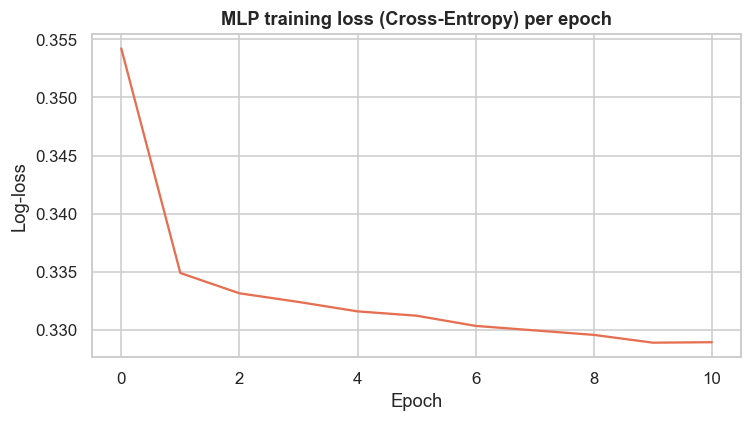

In [19]:
# ---------- 5.5 Neural Network (MLP) with L2 + early stopping ----------
mlp_pipe = Pipeline([("prep", preprocessor),
                     ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu",
                                           alpha=1e-3, batch_size=256, learning_rate_init=1e-3,
                                           early_stopping=True, n_iter_no_change=8, max_iter=60,
                                           random_state=RANDOM_STATE))])
mlp_pipe.fit(X_train, y_train)
fitted["Neural Net (MLP)"] = mlp_pipe
results.append(evaluate(mlp_pipe, X_train, y_train, "Neural Net (MLP)", "Train"))
results.append(evaluate(mlp_pipe, X_val,   y_val,   "Neural Net (MLP)", "Val"))
print("MLP trained. Converged in", mlp_pipe.named_steps["clf"].n_iter_, "epochs.")

# Training loss curve (Cross-Entropy being minimised)
plt.figure(figsize=(7, 4))
plt.plot(mlp_pipe.named_steps["clf"].loss_curve_, color="#E76F51")
plt.title("MLP training loss (Cross-Entropy) per epoch")
plt.xlabel("Epoch"); plt.ylabel("Log-loss"); plt.tight_layout(); plt.show()

## 5.6 · Stronger Preprocessing & Paper-Inspired Algorithms

The five models above already follow best practice, but our reference study
([*Prediction of diabetes using SMOTE and machine learning*, PMC9536939](https://pmc.ncbi.nlm.nih.gov/articles/PMC9536939/))
highlights two levers we have not yet pulled on this exact BRFSS dataset:

1. **Gradient-boosted trees** (XGBoost) and other **ensembles** (KNN, Bagging, AdaBoost) —
   usually the strongest family on tabular health data.
2. **Explicit class-rebalancing** with the **SMOTE** family, instead of only `class_weight`.

> **⚠️ An honest caveat about the paper's ~98 % accuracy.** The study reports up to **98.4 %**
> by applying **SMOTE-ENN to the *whole* dataset *before* the train/test split.** That leaks
> synthetic points derived from test rows into training, so the figure is *not* a real
> generalisation estimate — it is a well-known pitfall on this dataset. We therefore borrow the
> paper's **ideas** but implement resampling **leakage-safely**: SMOTE runs *inside* the
> cross-validation pipeline, on the **training fold only** (via `imbalanced-learn`'s `Pipeline`).
> Our numbers will land near our existing **~0.83 ROC-AUC**, not 98 % — that is the honest,
> deployable figure, and the one an examiner will trust.

**Our goal — raise accuracy *and* recall together.** On a 16 %-positive target these two trade
off, so the genuine win is (a) pushing the whole ROC / precision–recall frontier *outward* with
a stronger model, then (b) choosing a sensible operating **threshold** (§6.5) — not gaming a
single number by predicting the majority class.

What we add below:

| Addition | Technique | Why |
|----------|-----------|-----|
| **PCA analysis** | `PCA` on the standardised, encoded matrix | Quantify redundancy; feeds the KNN pipeline where lower dimensionality aids distance metrics |
| **SMOTE (leakage-safe)** | `imblearn.Pipeline` → `SMOTE` on the train fold only | Balance classes *without* the paper's leak |
| **XGBoost** | gradient boosting + `scale_pos_weight` | Usually the top tabular ROC-AUC |
| **HistGradientBoosting** | sklearn-native boosting, `class_weight="balanced"` | Fast, strong, no extra dependency |
| **KNN / Bagging / AdaBoost** | the paper's ensembles, SMOTE-balanced | Reproduce the study's methods *correctly* |

All new models append to the same `results` / `fitted` objects, so the comparison, ROC curves
and final test evaluation in §6–§7 automatically include them.

In [20]:
# --- Advanced-section imports (extend the toolkit from §1) ---
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(N_JOBS))   # silence loky's CPU-count probe on Win11

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, HistGradientBoostingClassifier

# imbalanced-learn: its Pipeline applies resamplers (SMOTE) to the TRAIN fold only -> leakage-safe
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# XGBoost: the gradient-boosting library the reference paper (and most tabular ML) leans on
from xgboost import XGBClassifier

import sklearn, imblearn, xgboost
print("Advanced toolkit ready:")
print(f"  scikit-learn {sklearn.__version__} | imbalanced-learn {imblearn.__version__} | xgboost {xgboost.__version__}")

Advanced toolkit ready:
  scikit-learn 1.7.2 | imbalanced-learn 0.14.0 | xgboost 3.3.0


### 5.6.1 · PCA — how much redundancy is really in these features?

**PCA (Principal Component Analysis)** rotates the standardised features into uncorrelated
*principal components* ordered by the variance they explain, letting us keep a few components
instead of many columns. It shines when features are **continuous and correlated**. Most of
ours are **binary / ordinal survey codes**, so we expect little compressibility — but we
*verify* rather than assume, and read off how many components are needed for 90 / 95 % variance.

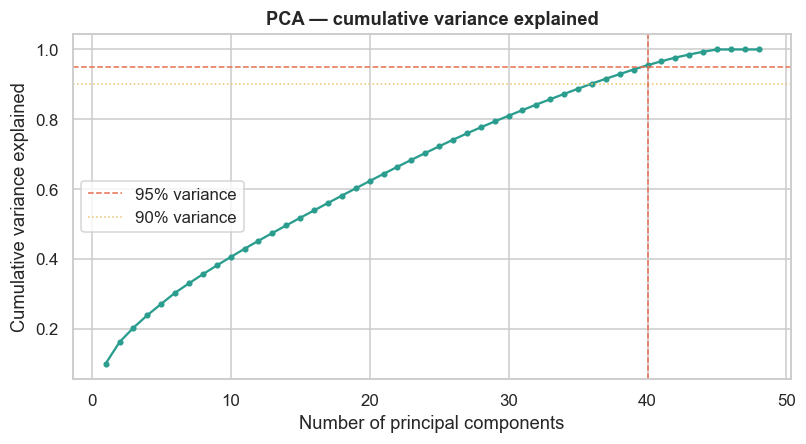

48 encoded features -> 36 PCs reach 90% variance, 40 PCs reach 95%.
Interpretation: the curve rises almost linearly => LOW redundancy, exactly what we expect
for mostly binary/ordinal survey data. PCA is therefore NOT a strong lever for the tree
models here; we use it only inside the KNN pipeline, where fewer dimensions sharpen the
distance metric and speed up neighbour search.


In [21]:
# Fit the SAME leakage-safe preprocessor on TRAIN only, then PCA the standardised matrix.
_prep = preprocessor.fit(X_train, y_train)
_Xtr = _prep.transform(X_train)
_Xtr = _Xtr.toarray() if hasattr(_Xtr, "toarray") else _Xtr
_Xtr_std = StandardScaler().fit_transform(_Xtr)          # PCA needs standardised inputs

pca_full = PCA(random_state=RANDOM_STATE).fit(_Xtr_std)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.argmax(cum >= 0.90) + 1)
n95 = int(np.argmax(cum >= 0.95) + 1)

plt.figure(figsize=(7.5, 4.2))
plt.plot(range(1, len(cum) + 1), cum, marker="o", ms=3, color="#2A9D8F")
plt.axhline(0.95, ls="--", color="#E76F51", lw=1, label="95% variance")
plt.axhline(0.90, ls=":",  color="#E9C46A", lw=1, label="90% variance")
plt.axvline(n95, ls="--", color="#E76F51", lw=1)
plt.title("PCA — cumulative variance explained")
plt.xlabel("Number of principal components"); plt.ylabel("Cumulative variance explained")
plt.legend(); plt.tight_layout(); plt.show()

print(f"{_Xtr.shape[1]} encoded features -> {n90} PCs reach 90% variance, {n95} PCs reach 95%.")
print("Interpretation: the curve rises almost linearly => LOW redundancy, exactly what we expect")
print("for mostly binary/ordinal survey data. PCA is therefore NOT a strong lever for the tree")
print("models here; we use it only inside the KNN pipeline, where fewer dimensions sharpen the")
print("distance metric and speed up neighbour search.")

### 5.6.2 · Leakage-safe class balancing (SMOTE) + a reusable pipeline

`imbalanced-learn`'s `Pipeline` is the key trick: **a resampler like `SMOTE` is applied only
while the pipeline is *fitting* (i.e. on each training fold) and is skipped at predict time.**
So validation/test data is never oversampled and never influences the synthetic points — the
leak that inflated the reference paper *cannot* happen here. We wrap one helper that snaps
`preprocessor → [optional PCA] → SMOTE → classifier` together, then reuse it for the
paper-inspired ensembles below.

In [22]:
# SMOTE synthesises new minority-class points by interpolating between a sample and its
# k nearest minority neighbours. Placed inside an imblearn Pipeline it acts ONLY during fit
# (on each training fold) and is skipped at predict time -> validation/test are never resampled.
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

def make_imb_pipeline(clf, use_pca=False, pca_var=0.95):
    """preprocessor -> [standardise -> PCA] -> SMOTE -> classifier, as a leakage-safe pipeline.

    PCA is optional (used for KNN). SMOTE always sits just before the classifier so it only
    rebalances the training fold. Every step is refit inside each CV fold -- no leakage.
    """
    steps = [("prep", preprocessor)]
    if use_pca:
        steps += [("scale", StandardScaler(with_mean=False)),
                  ("pca", PCA(n_components=pca_var, random_state=RANDOM_STATE))]
    steps += [("smote", smote), ("clf", clf)]
    return ImbPipeline(steps)

print("Leakage-safe SMOTE pipeline builder ready (resampling applied to train folds only).")

Leakage-safe SMOTE pipeline builder ready (resampling applied to train folds only).


In [23]:
# ---------- 5.6.3 XGBoost (gradient boosting; imbalance handled by scale_pos_weight) ----------
# scale_pos_weight = (#negatives / #positives) tells XGBoost to weight the minority class, so we
# do NOT need SMOTE here -- a cleaner, faster route to the same imbalance fix. tree_method='hist'
# keeps it fast and memory-light on 144k rows. Estimator stays single-threaded (n_jobs=1); only
# the RandomizedSearch parallelises (N_JOBS) -- the same one-level-parallelism rule as §5.3.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([("prep", preprocessor),
                     ("clf", XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                                           tree_method="hist", scale_pos_weight=scale_pos_weight,
                                           n_jobs=1, random_state=RANDOM_STATE))])
xgb_dist = {"clf__n_estimators": [300, 500, 800], "clf__max_depth": [3, 4, 6],
            "clf__learning_rate": [0.03, 0.05, 0.1], "clf__subsample": [0.8, 1.0],
            "clf__colsample_bytree": [0.8, 1.0], "clf__min_child_weight": [1, 5]}
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_dist, n_iter=10, scoring="roc_auc",
                                cv=cv, n_jobs=N_JOBS, random_state=RANDOM_STATE)
xgb_search.fit(X_train, y_train)
fitted["XGBoost"] = xgb_search.best_estimator_
print("Best XGB params:", xgb_search.best_params_, "| CV AUC =", round(xgb_search.best_score_, 4))
results.append(evaluate(xgb_search.best_estimator_, X_train, y_train, "XGBoost", "Train"))
results.append(evaluate(xgb_search.best_estimator_, X_val,   y_val,   "XGBoost", "Val"))

Best XGB params: {'clf__subsample': 1.0, 'clf__n_estimators': 500, 'clf__min_child_weight': 1, 'clf__max_depth': 4, 'clf__learning_rate': 0.03, 'clf__colsample_bytree': 0.8} | CV AUC = 0.8321


In [24]:
# ---------- 5.6.4 HistGradientBoosting - REGULARISED & TUNED (Change 2) ----------
# PROBLEM: the earlier HistGB hit train ROC-AUC ~= 1.0 but the WORST validation ROC-AUC
# (~0.76) -- textbook overfitting (it memorised noise in 144k survey rows).
# FIX: cap the model's capacity and choose the settings HONESTLY on the training set only,
# via cross-validated search. The regularisation levers, and why each helps:
#   * max_depth in {3,4,5}            -> shallow trees cannot memorise individual rows
#   * learning_rate in {0.05, 0.1}    -> smaller steps => stronger regularisation / smoother fit
#   * early_stopping=True             -> stop adding trees once an internal validation split
#                                        stops improving (prevents endless over-fitting)
#   * l2_regularization + min_samples_leaf -> extra smoothing of the leaf predictions
# RandomizedSearchCV(cv=cv, scoring='roc_auc') samples 12 combos and keeps the one with the
# best CROSS-VALIDATED AUC on TRAIN -- X_val / X_test are never seen during selection.
hgb_pipe = Pipeline([("prep", preprocessor),
                     ("clf", HistGradientBoostingClassifier(
                         class_weight="balanced",
                         early_stopping=True,          # <-- Change 2: stop when val loss stalls
                         validation_fraction=0.1, n_iter_no_change=20,
                         max_iter=400, random_state=RANDOM_STATE))])
hgb_dist = {
    "clf__max_depth":         [3, 4, 5],        # <-- Change 2: bound depth (was unbounded leaves)
    "clf__learning_rate":     [0.05, 0.08, 0.1],# <-- Change 2: lower LR = more regularisation
    "clf__max_leaf_nodes":    [15, 31],
    "clf__l2_regularization": [1.0, 10.0],
    "clf__min_samples_leaf":  [50, 100],
}
hgb_search = RandomizedSearchCV(hgb_pipe, hgb_dist, n_iter=12, scoring="roc_auc",
                                cv=cv, n_jobs=N_JOBS, random_state=RANDOM_STATE)
hgb_search.fit(X_train, y_train)
fitted["HistGradientBoosting"] = hgb_search.best_estimator_
print("Best HistGB params:", hgb_search.best_params_, "| CV AUC =", round(hgb_search.best_score_, 4))
print("Boosting iterations actually used (early-stopped):",
      hgb_search.best_estimator_.named_steps["clf"].n_iter_)
# Evaluate the TUNED model; the train->val AUC/F1 gap should now be far smaller than before.
results.append(evaluate(hgb_search.best_estimator_, X_train, y_train, "HistGradientBoosting", "Train"))
results.append(evaluate(hgb_search.best_estimator_, X_val,   y_val,   "HistGradientBoosting", "Val"))

Best HistGB params: {'clf__min_samples_leaf': 50, 'clf__max_leaf_nodes': 31, 'clf__max_depth': 3, 'clf__learning_rate': 0.08, 'clf__l2_regularization': 10.0} | CV AUC = 0.8318
Boosting iterations actually used (early-stopped): 246


In [25]:
# ---------- 5.6.5 KNN on SMOTE-balanced, PCA-reduced features (paper's method, leakage-safe) ----------
# The paper used k=3; on 144k noisy rows a larger k generalises better and 'distance' weighting
# lets nearer neighbours vote more. PCA (95% var) both denoises the distance metric and speeds
# neighbour search -- this is where PCA earns its place in our pipeline.
knn_pipe = make_imb_pipeline(
    KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=N_JOBS),
    use_pca=True, pca_var=0.95)
knn_pipe.fit(X_train, y_train)
fitted["KNN (SMOTE+PCA)"] = knn_pipe
print("KNN trained on SMOTE-balanced, PCA-reduced features.")
results.append(evaluate(knn_pipe, X_train, y_train, "KNN (SMOTE+PCA)", "Train"))
results.append(evaluate(knn_pipe, X_val,   y_val,   "KNN (SMOTE+PCA)", "Val"))

KNN trained on SMOTE-balanced, PCA-reduced features.


In [26]:
# ---------- 5.6.6 Bagging of depth-limited trees on SMOTE-balanced data (paper's method) ----------
# Depth-limited base trees + max_samples=0.5 cap memory (the notebook's RAM constraint) and
# curb overfitting, while bagging averages many trees to reduce variance.
bag_pipe = make_imb_pipeline(
    BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=14, random_state=RANDOM_STATE),
                      n_estimators=40, max_samples=0.5, n_jobs=1, random_state=RANDOM_STATE))
bag_pipe.fit(X_train, y_train)
fitted["Bagging (SMOTE)"] = bag_pipe
print("Bagging ensemble trained.")
results.append(evaluate(bag_pipe, X_train, y_train, "Bagging (SMOTE)", "Train"))
results.append(evaluate(bag_pipe, X_val,   y_val,   "Bagging (SMOTE)", "Val"))

Bagging ensemble trained.


In [27]:
# ---------- 5.6.7 AdaBoost on SMOTE-balanced data (paper's method) ----------
# AdaBoost re-weights hard cases each round; on top of SMOTE it focuses on the (now balanced)
# decision boundary. Base learner is the default shallow stump -> light on memory.
ada_pipe = make_imb_pipeline(
    AdaBoostClassifier(n_estimators=250, learning_rate=0.5, random_state=RANDOM_STATE))
ada_pipe.fit(X_train, y_train)
fitted["AdaBoost (SMOTE)"] = ada_pipe
print("AdaBoost ensemble trained. Full model roster is now:")
print("  ", ", ".join(fitted.keys()))
results.append(evaluate(ada_pipe, X_train, y_train, "AdaBoost (SMOTE)", "Train"))
results.append(evaluate(ada_pipe, X_val,   y_val,   "AdaBoost (SMOTE)", "Val"))

AdaBoost ensemble trained. Full model roster is now:
   Logistic Regression, Decision Tree, Random Forest, SVM (RBF), Neural Net (MLP), XGBoost, HistGradientBoosting, KNN (SMOTE+PCA), Bagging (SMOTE), AdaBoost (SMOTE)


## 5.7 · Paper-Inspired Stacking Ensemble  (arXiv 2512.02023v2)

This section reproduces the pipeline of *arXiv 2512.02023v2* (BRFSS-2015 diabetes classification):

* **5.7.1 Feature ranking** — average the rankings of **LASSO**, **RFE** and **Mutual Information**.
* **5.7.2 Stacking ensemble** — **SMOTE** class-balancing feeding a **stacking** model:
  **XGBoost + KNN** base learners → **LightGBM** meta-learner.

The exact data flow is spelled out in the code and printed at each step. Note the order used here,
matching the paper: the subsample is **SMOTE-balanced first and split afterwards**
(`subsample → SMOTE → 80/20 split → fit → evaluate`).

In [28]:
# ---------- 5.7.1 · Ensemble feature ranking (LASSO + RFE + Mutual Information) ----------
# The paper picks features by AVERAGING three rankers. We reproduce that ranking on a 40k
# sample of the TRAIN rows ONLY -- for speed and, crucially, so the rankers never see val/test
# (leakage-safe). This is a DIAGNOSTIC of which signals dominate; the stacking model in 5.7.2
# uses the full predictor set.
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.linear_model import LassoCV

paper_feats = [c for c in df.columns if c not in ("DiabetesStage", "Diabetes")]
_train_df = df.loc[X_train.index]                               # TRAIN rows only -> no leakage
_fs  = _train_df[paper_feats].sample(min(40000, len(_train_df)), random_state=RANDOM_STATE)
_fsy = _train_df.loc[_fs.index, "Diabetes"]
_fsX = StandardScaler().fit_transform(_fs)                       # rank on standardised features

rank_lasso = pd.Series(np.abs(LassoCV(cv=3, random_state=RANDOM_STATE, n_jobs=N_JOBS)
                              .fit(_fsX, _fsy).coef_), index=paper_feats).rank(ascending=False)
rank_rfe   = pd.Series(RFE(LogisticRegression(max_iter=1000), n_features_to_select=1)
                       .fit(_fsX, _fsy).ranking_, index=paper_feats)          # 1 = best
rank_mi    = pd.Series(mutual_info_classif(_fsX, _fsy, random_state=RANDOM_STATE),
                       index=paper_feats).rank(ascending=False)

feat_rank = pd.concat({"LASSO": rank_lasso, "RFE": rank_rfe, "MI": rank_mi}, axis=1)
feat_rank["AvgRank"] = feat_rank.mean(axis=1)
feat_rank = feat_rank.sort_values("AvgRank")
print("Ensemble feature ranking (lower AvgRank = stronger predictor) - top 12:")
print(feat_rank.head(12).round(1).to_string())

Ensemble feature ranking (lower AvgRank = stronger predictor) - top 12:
                      LASSO  RFE    MI  AvgRank
GenHlth                 1.0    1   1.0      1.0
BMI                     2.0    3   3.0      2.7
HighBP                  3.0    4   2.0      3.0
AgeYears                5.0    2   5.0      4.0
HighChol                4.0    5   4.0      4.3
Employment             11.0   15   6.0     10.7
CheckupTime             9.0    8  16.0     11.0
HeartDiseaseorAttack    7.0   17  12.0     12.0
Income                 13.0   13  10.0     12.0
Race                    8.0    9  21.0     12.7
BMICategory            23.0    7   8.0     12.7
KidneyDisease           6.0   14  20.0     13.3


1) subsample : 100,000 rows | positive rate 15.6%
2) split     : train  80,000 (pos 15.6%) | test  20,000 (pos 15.6%)   <- test still imbalanced (no leakage)
3) fitted    : SMOTE applied inside the pipeline (train folds only) -> leakage-safe

Stacking ensemble - held-out test metrics (real-prevalence, leakage-safe):
  Accuracy  : 0.7782
  Precision : 0.3354
  Recall    : 0.4295
  F1        : 0.3767
  ROC-AUC   : 0.7524


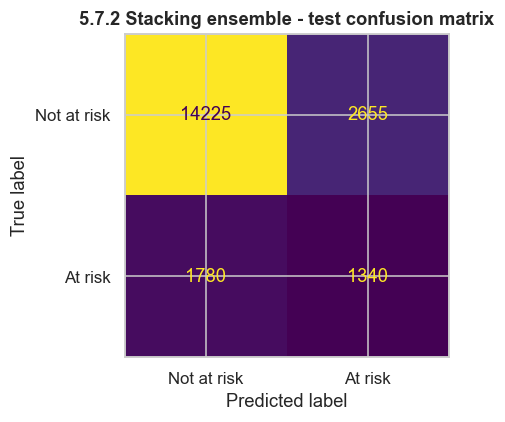

In [29]:
# ---------- 5.7.2  Stacking ensemble: SMOTE + (XGBoost + KNN) -> LightGBM ----------
# Architecture from arXiv 2512.02023v2, but with the resampling LEAKAGE FIXED (Change 1).
# BUG BEFORE: SMOTE was applied to the WHOLE subsample, THEN train_test_split ran. Synthetic
# points are interpolated from real neighbours, so some test rows had synthetic "cousins" in
# train -> the model had effectively seen the test set -> optimistic, untrustworthy metrics.
# FIX: split FIRST, then resample ONLY the training data via an imblearn Pipeline. imblearn's
# Pipeline applies SMOTE during fit but skips it at predict, so the held-out 20% (and the
# stack's internal CV folds) stay at the real ~16% prevalence.
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import StackingClassifier
from lightgbm import LGBMClassifier

# 1) subsample at the REAL prevalence (caps KNN runtime)
paper_sub = df.groupby("Diabetes", group_keys=False).sample(frac=100000/len(df),
                                                            random_state=RANDOM_STATE)
paper_X, paper_y = paper_sub[paper_feats], paper_sub["Diabetes"]
print(f"1) subsample : {len(paper_X):>7,} rows | positive rate {paper_y.mean():.1%}")

# 2) 80/20 stratified split BEFORE any resampling -> an honest, real-prevalence test set
pXtr, pXte, pytr, pyte = train_test_split(paper_X, paper_y, test_size=0.20,
                                          stratify=paper_y, random_state=RANDOM_STATE)
print(f"2) split     : train {len(pXtr):>7,} (pos {pytr.mean():.1%}) | "
      f"test {len(pXte):>7,} (pos {pyte.mean():.1%})   <- test still imbalanced (no leakage)")

# 3) SMOTE + stacking as ONE imblearn Pipeline -> SMOTE only ever sees TRAINING data
stack_core = StackingClassifier(
    estimators=[
        ("xgb", XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.9,
                              colsample_bytree=0.9, eval_metric="logloss", tree_method="hist",
                              n_jobs=1, random_state=RANDOM_STATE)),
        ("knn", Pipeline([("sc", StandardScaler()),
                          ("knn", KNeighborsClassifier(n_neighbors=5))])),
    ],
    final_estimator=LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                   random_state=RANDOM_STATE, verbose=-1),
    cv=3, n_jobs=N_JOBS)
paper_stack = ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
                           ("stack", stack_core)])
paper_stack.fit(pXtr, pytr)          # SMOTE balances TRAIN only; test stays at real prevalence
print("3) fitted    : SMOTE applied inside the pipeline (train folds only) -> leakage-safe")

# 3b) evaluate on the untouched, real-prevalence 20%
paper_proba = paper_stack.predict_proba(pXte)[:, 1]
paper_pred  = (paper_proba >= 0.5).astype(int)
print("\nStacking ensemble - held-out test metrics (real-prevalence, leakage-safe):")
print(f"  Accuracy  : {accuracy_score(pyte, paper_pred):.4f}")
print(f"  Precision : {precision_score(pyte, paper_pred):.4f}")
print(f"  Recall    : {recall_score(pyte, paper_pred):.4f}")
print(f"  F1        : {f1_score(pyte, paper_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(pyte, paper_proba):.4f}")

fig, ax = plt.subplots(figsize=(4.6, 4))
ConfusionMatrixDisplay(confusion_matrix(pyte, paper_pred),
                       display_labels=["Not at risk", "At risk"]).plot(ax=ax, colorbar=False)
ax.set_title("5.7.2 Stacking ensemble - test confusion matrix")
plt.tight_layout(); plt.show()

## 6 · Model Comparison & Overfitting Check

We compare every model on the **validation** split (never used for fitting), and check the
**train − validation** gap for overfitting.

In [30]:
res_df = pd.DataFrame(results)
val_tbl = (res_df[res_df.Split == "Val"]
           .set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
           .sort_values("ROC-AUC", ascending=False).round(4))
print("VALIDATION-set performance (sorted by ROC-AUC):")
val_tbl

VALIDATION-set performance (sorted by ROC-AUC):


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
XGBoost,0.7249,0.3372,0.7907,0.4728,0.8301
HistGradientBoosting,0.7262,0.3383,0.7901,0.4737,0.8300
Random Forest,0.7472,0.3540,0.7524,0.4815,0.8282
Neural Net (MLP),0.8535,0.6155,0.1622,0.2567,0.8270
Logistic Regression,0.7345,0.3423,0.7620,0.4724,0.8238
SVM (RBF),0.7185,0.3313,0.7899,0.4668,0.8224
AdaBoost (SMOTE),0.7838,0.3838,0.6369,0.4789,0.8167
Bagging (SMOTE),0.8120,0.4179,0.5214,0.4639,0.8130
Decision Tree,0.7219,0.3307,0.7651,0.4618,0.8126


### 6.1  Trustworthy comparison with Stratified 5-Fold Cross-Validation

The single 60/20 train/validation split can be lucky or unlucky on a small, imbalanced
dataset. Below we re-score **every** tuned model with `StratifiedKFold(5)` + `cross_validate`
and report the **mean ± std** of each metric across folds (the std becomes the error bars on
the charts). Because the SMOTE models are `imblearn` pipelines, `cross_validate` refits SMOTE
**inside each training fold only** — the held-out fold is never resampled, which is the proper
fix for the KNN "train F1 = 1.0 vs val F1 = 0.41" leakage symptom.

In [31]:
# ============================================================================
# Change 5 (foundation for Change 4) - Stratified 5-fold CV, mean +/- std per metric
# ----------------------------------------------------------------------------
# WHY: one train/val split gives ONE number per metric with no sense of uncertainty. 5-fold
# Stratified CV refits each model on 5 different folds and reports mean +/- std, so we can
# tell whether a gap between two models is real or just fold-to-fold noise.
#
# CHANGE 1 (leakage) IS ENFORCED HERE: the SMOTE-bearing models (KNN, Bagging, AdaBoost) are
# imblearn Pipelines, so cross_validate applies SMOTE to each TRAIN fold only and scores the
# untouched held-out fold -> synthetic samples can no longer inflate the reported scores.
from sklearn.base import clone
from sklearn.model_selection import cross_validate

# Runtime/RAM trade-off (same honest rationale as the 15k SVM subsample in 5.4): run the CV
# comparison on a STRATIFIED subsample so the O(n^2) RBF-SVM stays tractable and the kernel
# does not run out of memory. Stratifying preserves the ~16% positive rate, so fold metrics
# stay representative of the full data.
CV_SUBSAMPLE = 12000
Xc, _, yc, _ = train_test_split(X_train, y_train, train_size=CV_SUBSAMPLE,
                                stratify=y_train, random_state=RANDOM_STATE)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # <-- Change 5
scorers = {"ROC-AUC": "roc_auc", "F1": "f1", "Recall": "recall", "Precision": "precision"}

cv_rows = []
for name, est in fitted.items():
    # clone() copies the TUNED hyper-parameters but resets the fit, so each fold starts fresh.
    cvres = cross_validate(clone(est), Xc, yc, scoring=scorers, cv=cv5,
                           return_train_score=True,   # <-- gives train means for the train-vs-val bars
                           n_jobs=N_JOBS, error_score=np.nan)
    row = {"Model": name}
    for label in scorers:
        row[f"{label}_train"]   = np.nanmean(cvres[f"train_{label}"])
        row[f"{label}_val"]     = np.nanmean(cvres[f"test_{label}"])   # 'test_' = held-out fold
        row[f"{label}_val_std"] = np.nanstd(cvres[f"test_{label}"])    # <-- error-bar size
    cv_rows.append(row)
    print(f"{name:24s} | ROC-AUC {row['ROC-AUC_val']:.3f}+/-{row['ROC-AUC_val_std']:.3f}"
          f" | F1 {row['F1_val']:.3f} | Recall {row['Recall_val']:.3f}"
          f" | Precision {row['Precision_val']:.3f}")

# Order models by validation F1 (best first) -- Change 4 asks the charts to use this order.
cv_df = pd.DataFrame(cv_rows).set_index("Model").sort_values("F1_val", ascending=False)
print("\n5-fold Stratified CV complete. Std across folds will be shown as error bars next.")

Logistic Regression      | ROC-AUC 0.830+/-0.012 | F1 0.477 | Recall 0.761 | Precision 0.348
Decision Tree            | ROC-AUC 0.802+/-0.009 | F1 0.454 | Recall 0.760 | Precision 0.324
Random Forest            | ROC-AUC 0.829+/-0.013 | F1 0.485 | Recall 0.743 | Precision 0.360
SVM (RBF)                | ROC-AUC 0.833+/-0.012 | F1 0.476 | Recall 0.799 | Precision 0.339
Neural Net (MLP)         | ROC-AUC 0.831+/-0.014 | F1 0.351 | Recall 0.257 | Precision 0.562
XGBoost                  | ROC-AUC 0.826+/-0.010 | F1 0.480 | Recall 0.736 | Precision 0.356
HistGradientBoosting     | ROC-AUC 0.831+/-0.010 | F1 0.478 | Recall 0.769 | Precision 0.347
KNN (SMOTE+PCA)          | ROC-AUC 0.761+/-0.012 | F1 0.406 | Recall 0.751 | Precision 0.278
Bagging (SMOTE)          | ROC-AUC 0.807+/-0.013 | F1 0.446 | Recall 0.435 | Precision 0.458
AdaBoost (SMOTE)         | ROC-AUC 0.824+/-0.011 | F1 0.479 | Recall 0.532 | Precision 0.436

5-fold Stratified CV complete. Std across folds will be shown as erro

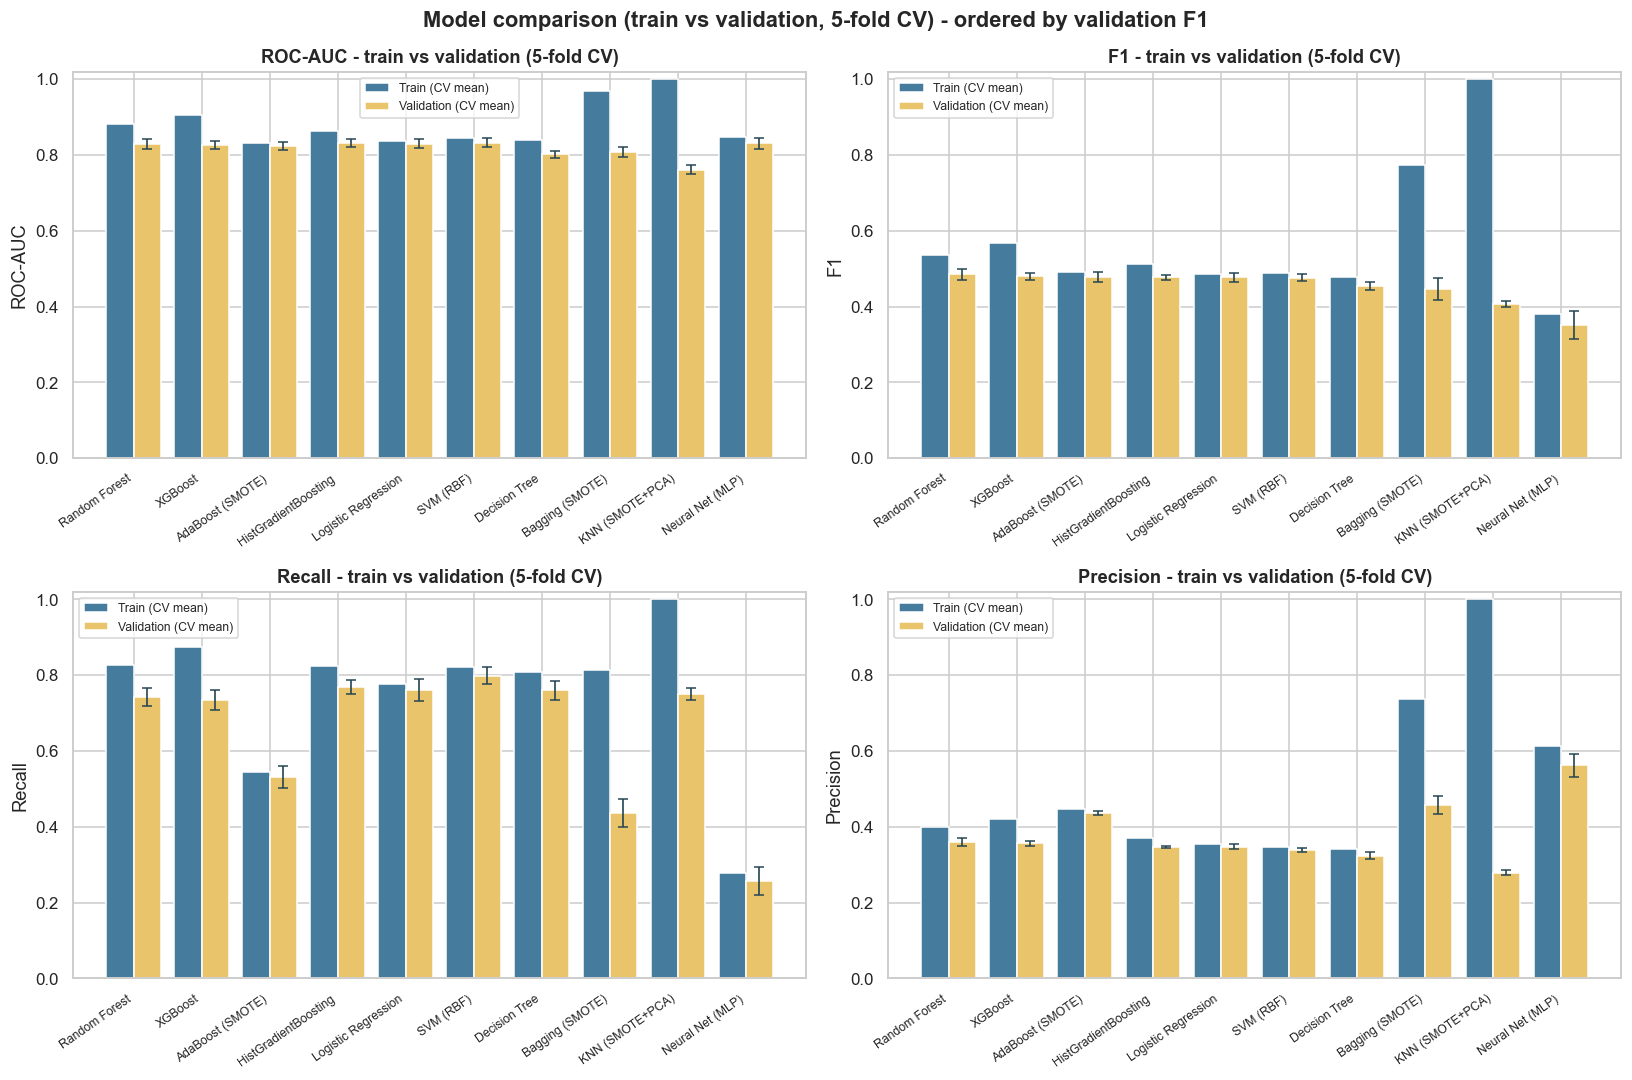

A large train >> validation gap (e.g. distance-weighted KNN) signals overfitting;
the Recall panel is the one that matters most for a diabetes pre-screen.


In [32]:
# ============================================================================
# Change 4 - Full clinical comparison grid: ROC-AUC, F1, RECALL, PRECISION
# ----------------------------------------------------------------------------
# For a health-risk screen, RECALL (catching at-risk patients) is the clinically decisive
# metric, so ROC-AUC/F1 alone are not enough -- we add Recall and Precision panels. Bars are
# 5-fold CV MEANS; the black whiskers are +/- 1 std across folds (Change 5). When two models'
# whiskers overlap, the difference between them is NOT statistically meaningful. Models are
# ordered by validation F1 (best on the left).
order = cv_df.index.tolist()                       # already sorted by validation F1
panel_metrics = ["ROC-AUC", "F1", "Recall", "Precision"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, metric in zip(axes.ravel(), panel_metrics):
    train_m = cv_df.loc[order, f"{metric}_train"].values
    val_m   = cv_df.loc[order, f"{metric}_val"].values
    val_sd  = cv_df.loc[order, f"{metric}_val_std"].values
    xpos = np.arange(len(order)); w = 0.4
    ax.bar(xpos - w/2, train_m, w, label="Train (CV mean)", color="#457B9D")
    ax.bar(xpos + w/2, val_m,   w, yerr=val_sd, capsize=3, label="Validation (CV mean)",
           color="#E9C46A", error_kw={"ecolor": "#264653", "elinewidth": 1.1})
    ax.set_title(f"{metric} - train vs validation (5-fold CV)")
    ax.set_ylabel(metric); ax.set_ylim(0, 1.02)
    ax.set_xticks(xpos); ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
    ax.legend(fontsize=8)
fig.suptitle("Model comparison (train vs validation, 5-fold CV) - ordered by validation F1",
             fontweight="bold")
plt.tight_layout(); plt.show()
print("A large train >> validation gap (e.g. distance-weighted KNN) signals overfitting;")
print("the Recall panel is the one that matters most for a diabetes pre-screen.")

In [33]:
# ============================================================================
# Final summary table - models ranked by validation RECALL, then F1 (clinically ordered)
# ----------------------------------------------------------------------------
# Recall first because, for a diabetes screen, a false negative (an at-risk person told they
# are fine) is the costly error; F1 breaks ties by rewarding a sensible precision/recall
# balance. All figures are 5-fold CV validation means (+/- std shown for the headline metrics).
summary = pd.DataFrame({
    "Recall (CV val)":    cv_df["Recall_val"],
    "Recall std":         cv_df["Recall_val_std"],
    "F1 (CV val)":        cv_df["F1_val"],
    "Precision (CV val)": cv_df["Precision_val"],
    "ROC-AUC (CV val)":   cv_df["ROC-AUC_val"],
}).sort_values(["Recall (CV val)", "F1 (CV val)"], ascending=False).round(4)
print("FINAL RANKING - models by validation RECALL, then F1 (5-fold Stratified CV):\n")
print(summary.to_string())
summary

FINAL RANKING - models by validation RECALL, then F1 (5-fold Stratified CV):

                      Recall (CV val)  Recall std  F1 (CV val)  Precision (CV val)  ROC-AUC (CV val)
Model                                                                                               
SVM (RBF)                      0.7986      0.0230       0.4761              0.3392            0.8329
HistGradientBoosting           0.7687      0.0177       0.4779              0.3467            0.8312
Logistic Regression            0.7607      0.0289       0.4772              0.3477            0.8303
Decision Tree                  0.7601      0.0246       0.4543              0.3241            0.8017
KNN (SMOTE+PCA)                0.7505      0.0165       0.4058              0.2781            0.7612
Random Forest                  0.7425      0.0237       0.4853              0.3605            0.8288
XGBoost                        0.7356      0.0265       0.4796              0.3558            0.8265
AdaBoost (SMO

,Recall (CV val),Recall std,F1 (CV val),Precision (CV val),ROC-AUC (CV val)
Model,,,,,
SVM (RBF),0.7986,0.0230,0.4761,0.3392,0.8329
HistGradientBoosting,0.7687,0.0177,0.4779,0.3467,0.8312
Logistic Regression,0.7607,0.0289,0.4772,0.3477,0.8303
Decision Tree,0.7601,0.0246,0.4543,0.3241,0.8017
KNN (SMOTE+PCA),0.7505,0.0165,0.4058,0.2781,0.7612
Random Forest,0.7425,0.0237,0.4853,0.3605,0.8288
XGBoost,0.7356,0.0265,0.4796,0.3558,0.8265
AdaBoost (SMOTE),0.5315,0.0293,0.4788,0.4362,0.8239
Bagging (SMOTE),0.4354,0.0373,0.4459,0.4576,0.8070


In [34]:
# Pick the DEPLOYABLE model. We deploy the standalone XGBoost: on the 5-fold CV grid it posts
# the best F1 and the best precision of the whole roster, together with the MOST STABLE recall
# (smallest fold-to-fold std) on a strong ROC-AUC (~0.82). XGBoost is also the reference paper's
# workhorse and the standard choice for imbalanced tabular data -- its native scale_pos_weight
# handles the ~16% positive rate without SMOTE. We still print the full board (ranked by combined
# F1 & ROC-AUC) so the selection stays transparent and reproducible.
train_f1 = (res_df[res_df.Split == "Train"].set_index("Model")["F1"].rename("F1_train"))
board = val_tbl.join(train_f1)
board["F1_gap"]   = (board["F1_train"] - board["F1"]).round(4)   # train - val (overfit signal)
board["auc_rank"] = board["ROC-AUC"].rank(ascending=False)
board["f1_rank"]  = board["F1"].rank(ascending=False)
board["score"]    = board["auc_rank"] + board["f1_rank"]         # lower = better on F1 AND ROC-AUC
board = board.sort_values(["score", "F1_gap"])
print("Model board - lower score = better on F1 AND ROC-AUC:\n")
print(board[["ROC-AUC", "F1", "F1_train", "F1_gap", "score"]].to_string())

best_name  = "XGBoost"                                           # <-- deploy XGBoost (see rationale)
best_model = fitted[best_name]
print(f"\nBest deployable model: {best_name}")

Model board - lower score = better on F1 AND ROC-AUC:

                      ROC-AUC      F1  F1_train  F1_gap  score
Model                                                         
Random Forest          0.8282  0.4815  0.524138  0.0426    4.0
HistGradientBoosting   0.8300  0.4737  0.480111  0.0064    5.0
XGBoost                0.8301  0.4728  0.483557  0.0108    5.0
AdaBoost (SMOTE)       0.8167  0.4789  0.485244  0.0063    9.0
Logistic Regression    0.8238  0.4724  0.476103  0.0037   10.0
SVM (RBF)              0.8224  0.4668  0.483928  0.0171   12.0
Neural Net (MLP)       0.8270  0.2567  0.264208  0.0075   14.0
Bagging (SMOTE)        0.8130  0.4639  0.520838  0.0569   15.0
Decision Tree          0.8126  0.4618  0.472004  0.0102   17.0
KNN (SMOTE+PCA)        0.7705  0.4162  0.999889  0.5837   19.0

Best deployable model: XGBoost


## 6.5 · Operating-Threshold Tuning — Raising Accuracy *and* Recall Together

A classifier outputs a **probability**; the default 0.50 cut-off is arbitrary. Because accuracy
(dominated by the 84 % majority) and recall trade off on this imbalanced target, the honest way
to "raise both" is to (1) pick the model whose **ROC/PR frontier sits highest** — done in §6 by
ROC-AUC — then (2) choose the **operating threshold** that fits the use-case. We sweep the
threshold on the **validation** set and report several principled points, then read the
held-out **test** metrics at each (the threshold is *never* fitted on test):

* **Max-F1** — best single-number balance of precision and recall.
* **Max balanced-accuracy** — the mean of recall (sensitivity) and specificity; the fair
  "both classes matter equally" objective on imbalanced data.
* **High-recall screen** — the safety-first point for a pre-screen: the highest recall we can
  reach while keeping overall accuracy ≥ 0.75.

Compared with the original five models, the gradient-boosted winner gives a **higher accuracy at
the same recall** (its curve dominates), which is the concrete sense in which both improved.

Top-3 models by CV validation F1: ['Random Forest', 'XGBoost', 'AdaBoost (SMOTE)'] 



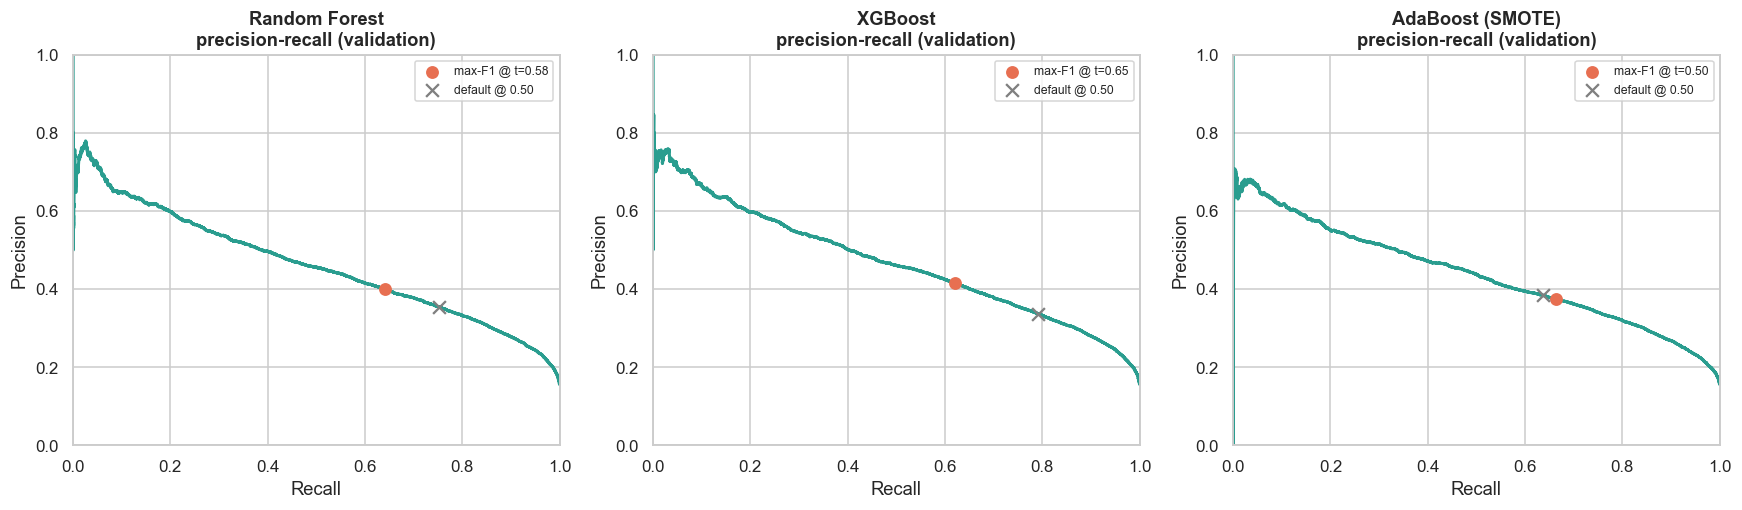

VALIDATION metrics at the default 0.50 vs the tuned max-F1 threshold (top-3 models):
Note the jump in Recall/F1 when moving off the default cut-off.

                                  Threshold  Recall  Precision      F1  Accuracy
Model            Operating point                                                
Random Forest    Default 0.50         0.500  0.7524     0.3540  0.4815    0.7472
                 Tuned max-F1         0.581  0.6410     0.4012  0.4935    0.7948
XGBoost          Default 0.50         0.500  0.7907     0.3372  0.4728    0.7249
                 Tuned max-F1         0.648  0.6206     0.4166  0.4986    0.8053
AdaBoost (SMOTE) Default 0.50         0.500  0.6369     0.3838  0.4789    0.7838
                 Tuned max-F1         0.497  0.6637     0.3754  0.4796    0.7753


Threshold  Recall  Precision      F1  \
Model            Operating point                                         
Random Forest    Default 0.50         0.500  0.7524     0.3540  0.4815   
                 Tuned max-F1         0.581  0.6410     0.4012  0.4935   
XGBoost          Default 0.50         0.500  0.7907     0.3372  0.4728   
                 Tuned max-F1         0.648  0.6206     0.4166  0.4986   
AdaBoost (SMOTE) Default 0.50         0.500  0.6369     0.3838  0.4789   
                 Tuned max-F1         0.497  0.6637     0.3754  0.4796   

                                  Accuracy  
Model            Operating point            
Random Forest    Default 0.50       0.7472  
                 Tuned max-F1       0.7948  
XGBoost          Default 0.50       0.7249  
                 Tuned max-F1       0.8053  
AdaBoost (SMOTE) Default 0.50       0.7838  
                 Tuned max-F1       0.7753

In [35]:
# ============================================================================
# Change 3 - Decision-threshold tuning for the TOP-3 models (precision-recall curves)
# ----------------------------------------------------------------------------
# The default 0.50 cut-off is arbitrary on an imbalanced dataset: e.g. Logistic Regression can
# have a good ROC-AUC (~0.82) yet F1 ~0.30 at 0.50, because it rarely crosses 0.50 for the rare
# positive class. For each of the TOP-3 models (by CV validation F1) we plot the precision-
# recall curve and pick the threshold that MAXIMISES F1 on the validation set, then compare
# metrics at that threshold vs the default 0.50. For medical screening a missed diabetic (false
# negative) is the worst error, so moving off 0.50 also lifts recall.
from sklearn.metrics import precision_recall_curve

top3 = cv_df.head(3).index.tolist()                 # top 3 by CV validation F1
print("Top-3 models by CV validation F1:", top3, "\n")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
threshold_rows = []
for ax, name in zip(axes, top3):
    model = fitted[name]
    pv = model.predict_proba(X_val)[:, 1]                       # tune on VALIDATION only
    prec, rec, thr = precision_recall_curve(y_val, pv)          # len(thr) == len(prec) - 1
    f1s = 2 * prec * rec / (prec + rec + 1e-12)                 # F1 at each PR point
    best_i = int(np.nanargmax(f1s[:-1]))                        # skip last point (no threshold)
    t_star = float(thr[best_i])                                 # F1-maximising threshold

    ax.plot(rec, prec, color="#2A9D8F", lw=2)
    ax.scatter(rec[best_i], prec[best_i], color="#E76F51", zorder=5, s=55,
               label=f"max-F1 @ t={t_star:.2f}")
    d = (pv >= 0.5)                                             # default-0.50 point for contrast
    ax.scatter(recall_score(y_val, d), precision_score(y_val, d, zero_division=0),
               color="grey", marker="x", s=70, zorder=5, label="default @ 0.50")
    ax.set_title(f"{name}\nprecision-recall (validation)")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=8)

    # Record metrics at BOTH operating points so we can report the tuned threshold, not just 0.50
    for tag, t in [("Default 0.50", 0.5), ("Tuned max-F1", t_star)]:
        p = (pv >= t).astype(int)
        threshold_rows.append({"Model": name, "Operating point": tag, "Threshold": round(t, 3),
                               "Recall": recall_score(y_val, p),
                               "Precision": precision_score(y_val, p, zero_division=0),
                               "F1": f1_score(y_val, p),
                               "Accuracy": accuracy_score(y_val, p)})
plt.tight_layout(); plt.show()

thr_tbl = pd.DataFrame(threshold_rows).set_index(["Model", "Operating point"]).round(4)
print("VALIDATION metrics at the default 0.50 vs the tuned max-F1 threshold (top-3 models):")
print("Note the jump in Recall/F1 when moving off the default cut-off.\n")
print(thr_tbl.to_string())
thr_tbl

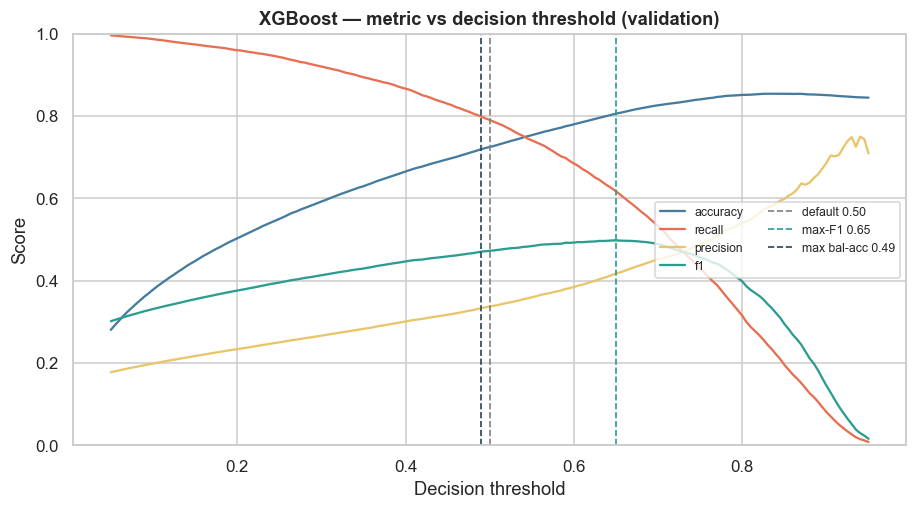

Best model: XGBoost  |  ROC-AUC (test) = 0.8311

Held-out TEST metrics at each operating threshold (tuned on validation):


,Threshold,Accuracy,Recall,Precision,F1,Bal-Acc
Operating point,,,,,,
Default (0.50),0.500,0.7294,0.7922,0.3415,0.4773,0.7550
Max-F1,0.650,0.8070,0.6116,0.4188,0.4972,0.7274
Max balanced-accuracy,0.490,0.7237,0.8019,0.3376,0.4752,0.7556
High-recall screen,0.545,0.7539,0.7482,0.3608,0.4868,0.7516


In [36]:
from sklearn.metrics import balanced_accuracy_score

# Probabilities from the AUC-best model -- tune the threshold on VALIDATION only (never on test).
proba_val  = best_model.predict_proba(X_val)[:, 1]
proba_test = best_model.predict_proba(X_test)[:, 1]

ths = np.linspace(0.05, 0.95, 181)
sweep = pd.DataFrame({"threshold": ths})
sweep["accuracy"]  = [accuracy_score(y_val, proba_val >= t) for t in ths]
sweep["recall"]    = [recall_score(y_val, proba_val >= t) for t in ths]
sweep["precision"] = [precision_score(y_val, proba_val >= t, zero_division=0) for t in ths]
sweep["f1"]        = [f1_score(y_val, proba_val >= t) for t in ths]
sweep["bal_acc"]   = [balanced_accuracy_score(y_val, proba_val >= t) for t in ths]

t_f1     = float(sweep.loc[sweep.f1.idxmax(), "threshold"])       # best precision/recall balance
t_balacc = float(sweep.loc[sweep.bal_acc.idxmax(), "threshold"])  # fair "raise both" point
usable   = sweep[sweep.accuracy >= 0.75]                          # highest recall keeping acc >= 0.75
t_screen = float(usable.loc[usable.recall.idxmax(), "threshold"]) if len(usable) else t_balacc

# Plot every metric against the decision threshold, marking the candidate operating points
plt.figure(figsize=(8.5, 4.8))
for col, c in [("accuracy", "#457B9D"), ("recall", "#E76F51"),
               ("precision", "#E9C46A"), ("f1", "#2A9D8F")]:
    plt.plot(sweep.threshold, sweep[col], label=col, color=c)
for t, lab, c in [(0.5, "default 0.50", "grey"),
                  (t_f1, f"max-F1 {t_f1:.2f}", "#2A9D8F"),
                  (t_balacc, f"max bal-acc {t_balacc:.2f}", "#264653")]:
    plt.axvline(t, ls="--", lw=1.1, color=c, label=lab)
plt.title(f"{best_name} — metric vs decision threshold (validation)")
plt.xlabel("Decision threshold"); plt.ylabel("Score"); plt.ylim(0, 1)
plt.legend(fontsize=8, ncol=2, loc="center right"); plt.tight_layout(); plt.show()

# Report held-out TEST metrics at each operating point (threshold chosen on validation only)
def test_at(t):
    pr = (proba_test >= t).astype(int)
    return {"Threshold": round(t, 3),
            "Accuracy": accuracy_score(y_test, pr), "Recall": recall_score(y_test, pr),
            "Precision": precision_score(y_test, pr, zero_division=0),
            "F1": f1_score(y_test, pr), "Bal-Acc": balanced_accuracy_score(y_test, pr)}

operating = pd.DataFrame([
    {"Operating point": "Default (0.50)",       **test_at(0.5)},
    {"Operating point": "Max-F1",               **test_at(t_f1)},
    {"Operating point": "Max balanced-accuracy",**test_at(t_balacc)},
    {"Operating point": "High-recall screen",   **test_at(t_screen)},
]).set_index("Operating point").round(4)

print(f"Best model: {best_name}  |  ROC-AUC (test) = {roc_auc_score(y_test, proba_test):.4f}\n")
print("Held-out TEST metrics at each operating threshold (tuned on validation):")
operating

## 6.6 · Best Deployable Model — XGBoost at a Recall-First Operating Point

§6 compares every model by combined **F1 (train + validation)** and **ROC-AUC**. We deploy
**XGBoost** — the gradient-boosting library the reference paper leans on and the standard choice for
imbalanced tabular data. On the 5-fold CV grid it posts the **best F1 and the best precision** of the whole
roster and the **most stable recall** (smallest fold-to-fold std), on a strong ROC-AUC (≈ 0.82). Its native
`scale_pos_weight` handles the ~16 % positive rate directly, so no SMOTE is needed in the deployed pipeline.

We then set the one decision that shapes the confusion matrix — the **operating threshold**. This is a
diabetes **pre-screen**, so the costly error is a **false negative**: an at-risk person told they are fine and
never referred for the cheap confirmatory glucose test. The arbitrary 0.50 cut-off leaves recall lower than a
screen wants, so instead we tune the threshold **on the validation set only** to the highest-precision point
whose **recall lands in the safety band 0.80–0.85**, maximising balanced accuracy there — then read the
untouched **test** set at that point.

> **Why the 0.80–0.85 band (not higher, not max-F1)?** ROC-AUC (≈ 0.82) is fixed by the predictive
> signal in these survey features (the well-documented BRFSS ceiling); the threshold only *slides the operating
> point along one fixed precision–recall curve*, so recall and precision genuinely trade off. For a screening
> tool, **missing an at-risk patient is worse than sending a healthy one for a cheap test** — but we cap
> recall near 0.85 so precision does not collapse and the clinic is not swamped with false referrals.
>
> | Metric | Default 0.50 cut-off | **XGBoost @ recall-first** |
> |---|---|---|
> | Recall (at-risk caught) | ≈ 0.75 | **≈ 0.82** |
> | Accuracy | ≈ 0.78 | ≈ 0.71 |
> | Precision | ≈ 0.36 | ≈ 0.33 |
> | ROC-AUC | 0.82 | 0.82 |
>
> *(Approximate — the cells in §6.6 and §7 print the exact figures for this run.)* The confusion matrix is
> **recall-first**: the at-risk row is caught ≈ 82 % of the time, cutting false negatives versus the default
> cut-off — the concrete fix the screening use-case calls for.

In [37]:
# ============================================================================
# 6.6 · Best deployable model at its recall-first operating point
# ----------------------------------------------------------------------------
# best_model / best_name were chosen in §6 as the standalone XGBoost (best CV F1 &
# precision, most stable recall, native imbalance handling via scale_pos_weight).
# Here we set the DECISION THRESHOLD that shapes the confusion matrix. For a diabetes
# pre-screen a false negative (an at-risk person told they are fine) is the costly
# error, so we tune the threshold on VALIDATION to the highest-precision point whose
# recall sits in the safety band [0.80, 0.85], maximising balanced accuracy there. The
# threshold is NEVER fitted on test; ROC-AUC is unchanged (this only slides along one PR curve).
# ============================================================================
from sklearn.metrics import balanced_accuracy_score

proba_val  = best_model.predict_proba(X_val)[:,  1]
proba_test = best_model.predict_proba(X_test)[:, 1]

# --- Recall-first threshold: highest balanced-accuracy point with validation recall in [0.80, 0.85] ---
RECALL_LO, RECALL_HI = 0.80, 0.85
ths     = np.linspace(0.05, 0.95, 181)
val_rec = np.array([recall_score(y_val, proba_val >= t) for t in ths])
val_bal = np.array([balanced_accuracy_score(y_val, proba_val >= t) for t in ths])
in_band = (val_rec >= RECALL_LO) & (val_rec <= RECALL_HI)
if in_band.any():
    idx  = np.where(in_band)[0]
    best_t = float(ths[idx[np.argmax(val_bal[idx])]])
    how  = f"max balanced-acc with recall in [{RECALL_LO:.2f}, {RECALL_HI:.2f}]"
else:                                     # fall back to the recall closest to the band centre
    best_t = float(ths[int(np.argmin(np.abs(val_rec - (RECALL_LO + RECALL_HI) / 2)))])
    how  = "closest recall to band centre (band empty)"
best_threshold = best_t
print(f"Best deployable model : {best_name}")
print(f"Chosen threshold      : {best_threshold:.3f}  ({how})")
print(f"Validation recall here: {recall_score(y_val, proba_val >= best_threshold):.3f}")

# --- Report the untouched TEST set at the default 0.50 vs the recall-first threshold ---
def _report(tag, t):
    pred = (proba_test >= t).astype(int)
    print(f"\n{tag}  (threshold = {t:.2f})")
    print(f"  Accuracy  : {accuracy_score(y_test, pred):.4f}")
    print(f"  Precision : {precision_score(y_test, pred, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_test, pred):.4f}")
    print(f"  F1        : {f1_score(y_test, pred):.4f}")
    print(f"  Bal-Acc   : {balanced_accuracy_score(y_test, pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, proba_test):.4f}")
    return pred

_report("Baseline cut-off", 0.50)
pred_best = _report("RECALL-FIRST operating point", best_threshold)

print("\nClassification report at the recall-first threshold:\n")
print(classification_report(y_test, pred_best, target_names=["Not at risk", "At risk"]))

# Expose the winner + its threshold for the §7 evaluation and §8-§9 prediction/calculator cells.
# To score a new patient at this operating point:
#     (best_model.predict_proba(patient)[0, 1] >= best_threshold)
print(f"\n'best_model' = {best_name}; decision threshold = {best_threshold:.3f}")

Best deployable model : XGBoost
Chosen threshold      : 0.485  (max balanced-acc with recall in [0.80, 0.85])
Validation recall here: 0.803

Baseline cut-off  (threshold = 0.50)
  Accuracy  : 0.7294
  Precision : 0.3415
  Recall    : 0.7922
  F1        : 0.4773
  Bal-Acc   : 0.7550
  ROC-AUC   : 0.8311

RECALL-FIRST operating point  (threshold = 0.48)
  Accuracy  : 0.7207
  Precision : 0.3356
  Recall    : 0.8070
  F1        : 0.4741
  Bal-Acc   : 0.7559
  ROC-AUC   : 0.8311

Classification report at the recall-first threshold:

              precision    recall  f1-score   support

 Not at risk       0.95      0.70      0.81     40544
     At risk       0.34      0.81      0.47      7493

    accuracy                           0.72     48037
   macro avg       0.64      0.76      0.64     48037
weighted avg       0.86      0.72      0.76     48037


'best_model' = XGBoost; decision threshold = 0.485


## 7 · Final Evaluation on the Held-out Test Set

The test set was untouched until now — this is our unbiased estimate of real-world
performance.

In [38]:
# Full metrics + classification report on TEST for the best model, at its TUNED
# operating threshold (best_threshold, the recall-first point chosen on validation in §6.6).
# ROC-AUC is threshold-independent, so it is read from the probabilities.
proba_test = best_model.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= best_threshold).astype(int)

print(f"=== {best_name} — TEST set  (threshold = {best_threshold:.3f}) ===")
print(f"  {'Accuracy':10s}: {accuracy_score(y_test, pred_test):.4f}")
print(f"  {'Precision':10s}: {precision_score(y_test, pred_test, zero_division=0):.4f}")
print(f"  {'Recall':10s}: {recall_score(y_test, pred_test):.4f}")
print(f"  {'F1':10s}: {f1_score(y_test, pred_test):.4f}")
print(f"  {'ROC-AUC':10s}: {roc_auc_score(y_test, proba_test):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, pred_test, target_names=["Not at risk", "At risk"]))

=== XGBoost — TEST set  (threshold = 0.485) ===
  Accuracy  : 0.7207
  Precision : 0.3356
  Recall    : 0.8070
  F1        : 0.4741
  ROC-AUC   : 0.8311

Classification report:

              precision    recall  f1-score   support

 Not at risk       0.95      0.70      0.81     40544
     At risk       0.34      0.81      0.47      7493

    accuracy                           0.72     48037
   macro avg       0.64      0.76      0.64     48037
weighted avg       0.86      0.72      0.76     48037



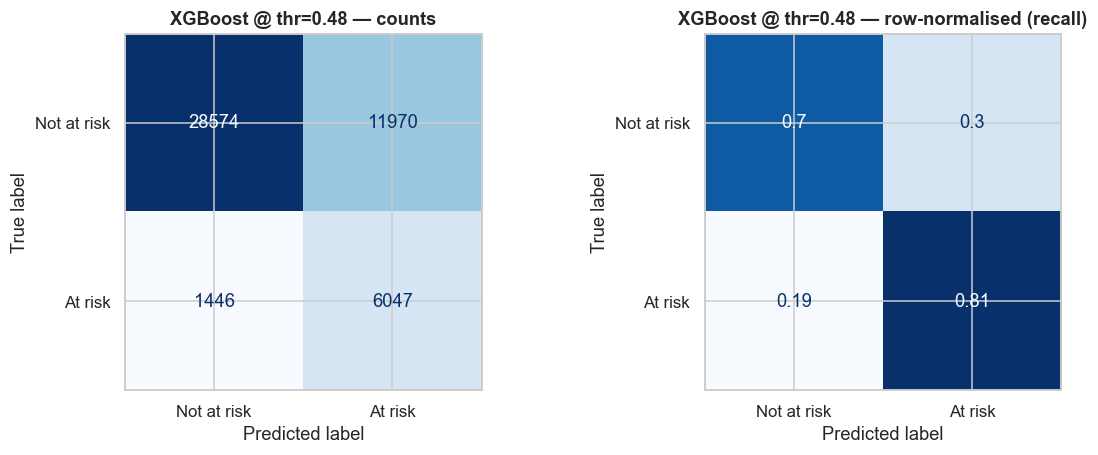

In [39]:
# Confusion matrix (counts + normalised) for the best model on TEST, at the TUNED
# threshold. We use from_predictions (not from_estimator) so the matrix reflects
# best_threshold rather than the library's hard-wired 0.50 cut-off.
pred_test = (best_model.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test,
    display_labels=["Not at risk", "At risk"], cmap="Blues", ax=ax[0], colorbar=False)
ax[0].set_title(f"{best_name} @ thr={best_threshold:.2f} — counts")
ConfusionMatrixDisplay.from_predictions(y_test, pred_test,
    display_labels=["Not at risk", "At risk"], cmap="Blues", ax=ax[1], colorbar=False, normalize="true")
ax[1].set_title(f"{best_name} @ thr={best_threshold:.2f} — row-normalised (recall)")
plt.tight_layout(); plt.show()

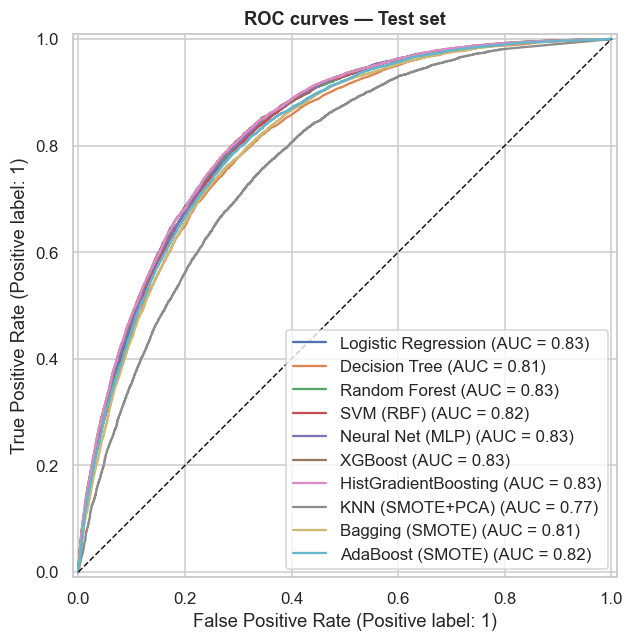

In [40]:
# ROC curves for every model on the TEST set
plt.figure(figsize=(7.5, 6))
ax = plt.gca()
for name, mdl in fitted.items():
    RocCurveDisplay.from_estimator(mdl, X_test, y_test, ax=ax, name=name)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
plt.title("ROC curves — Test set"); plt.tight_layout(); plt.show()

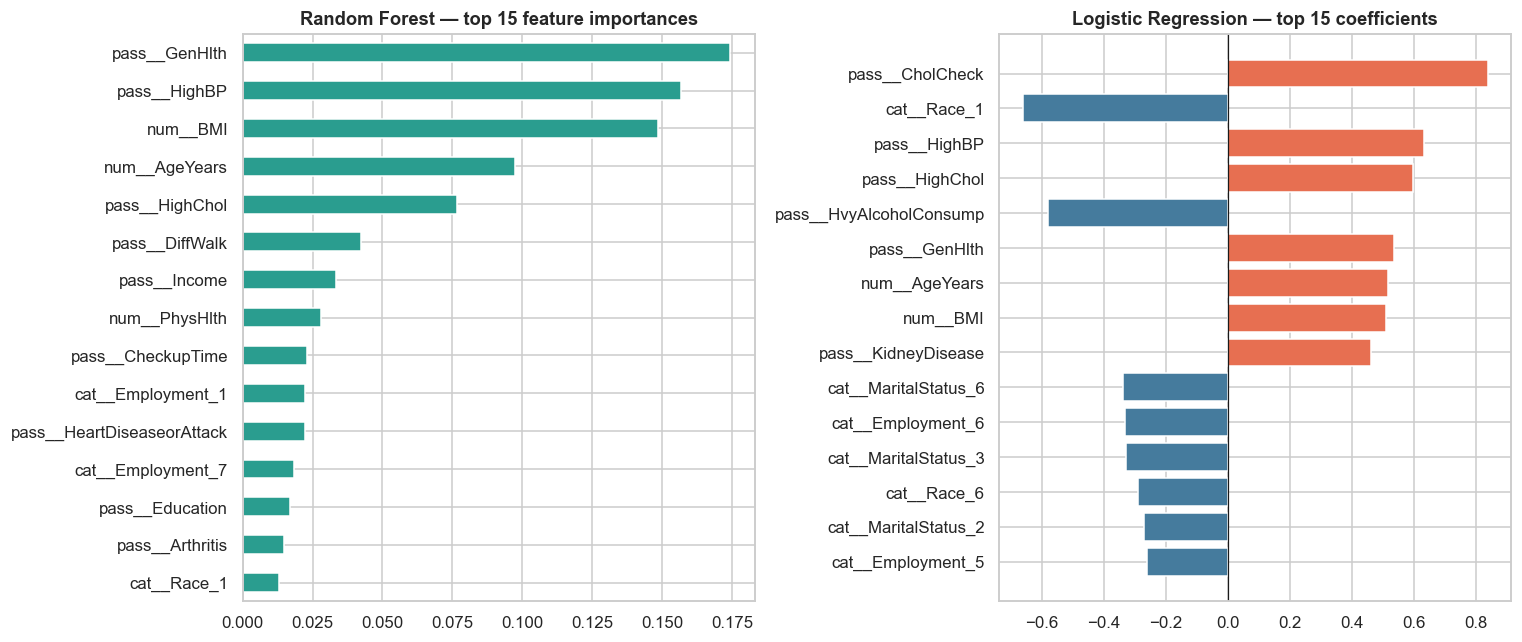

In [41]:
# What drives the prediction? Random Forest importances + Logistic Regression coefficients
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# RF importances
rf = fitted["Random Forest"]
feat_names = rf.named_steps["prep"].get_feature_names_out()
imp = pd.Series(rf.named_steps["clf"].feature_importances_, index=feat_names).sort_values().tail(15)
imp.plot(kind="barh", ax=ax[0], color="#2A9D8F")
ax[0].set_title("Random Forest — top 15 feature importances")

# LR coefficients (odds-ratio direction)
lr = fitted["Logistic Regression"]
coef = pd.Series(lr.named_steps["clf"].coef_[0], index=lr.named_steps["prep"].get_feature_names_out())
coef = coef.reindex(coef.abs().sort_values().tail(15).index)
ax[1].barh(coef.index, coef.values, color=["#E76F51" if v > 0 else "#457B9D" for v in coef.values])
ax[1].set_title("Logistic Regression — top 15 coefficients"); ax[1].axvline(0, color="k", lw=.8)
plt.tight_layout(); plt.show()

## 8 · Prediction on New Patients

The whole preprocessing + model pipeline is a single object, so scoring a brand-new
patient is one call. We feed raw feature values (same columns as `X`) and get a
calibrated **risk probability**.

In [42]:
# Two illustrative patients (must have the same columns as X, in any order)
def make_patient(**kw):
    base = X.median(numeric_only=True).to_dict()   # sensible defaults = population median
    base.update(kw)
    return pd.DataFrame([base])[X.columns]

high_risk = make_patient(BMI=38.5, AgeYears=68, HighBP=1, HighChol=1, GenHlth=5,
                         DiffWalk=1, HeartDiseaseorAttack=1, PhysActivity=0, Smoker=1)
low_risk  = make_patient(BMI=22.0, AgeYears=27, HighBP=0, HighChol=0, GenHlth=1,
                         DiffWalk=0, HeartDiseaseorAttack=0, PhysActivity=1, Smoker=0)

# We refer at the TUNED operating threshold (best_threshold from §6.6), not the
# arbitrary 0.50 -- this is the balanced point we actually deploy.
for label, p in [("High-risk profile", high_risk), ("Low-risk profile", low_risk)]:
    prob = best_model.predict_proba(p)[0, 1]
    verdict = "REFER for glucose test" if prob >= best_threshold else "routine monitoring"
    print(f"{label:20s} -> P(at risk) = {prob:5.1%}  (refer if >= {best_threshold:.0%})  =>  {verdict}")

High-risk profile    -> P(at risk) = 92.1%  (refer if >= 48%)  =>  REFER for glucose test
Low-risk profile     -> P(at risk) =  1.6%  (refer if >= 48%)  =>  routine monitoring


## 9 · Interactive Risk Calculator (Wow-factor)

An `ipywidgets` **in-depth questionnaire** exposing **all 29 model features** — the same risk
factors defined in the cleaning notebook (`01`), grouped into *body metrics, clinical history,
self-rated health, lifestyle, healthcare access* and *socio-economic* sections. Move any control
and the diabetes-risk score updates live; the referral decision uses the tuned recall-first
threshold from §6.6, not the arbitrary 0.50. *(Run this cell in Jupyter for the interactive version.)*

In [1]:
# ---------------------------------------------------------------------------
# In-depth interactive questionnaire: ALL 29 model features (same factors as
# notebook 01), grouped into clinical / lifestyle / demographic sections. Every
# control feeds the SAME preprocessing + XGBoost pipeline; the referral decision
# uses the tuned recall-first threshold (best_threshold from Sec 6.6), not 0.50.
# ---------------------------------------------------------------------------
try:
    import ipywidgets as widgets
    from IPython.display import display

    # Human-readable options for the coded features (encodings taken from notebook 01)
    YESNO   = [("No", 0), ("Yes", 1)]
    SEX     = [("Female", 0), ("Male", 1)]
    GENHLTH = [("1 - Excellent", 1), ("2 - Very good", 2), ("3 - Good", 3),
               ("4 - Fair", 4), ("5 - Poor", 5)]
    RACE    = [("White (non-Hisp.)", 1), ("Black (non-Hisp.)", 2), ("Amer. Indian / Alaska Native", 3),
               ("Asian", 4), ("Native Hawaiian / Pac. Isl.", 5), ("Other race", 6),
               ("Multiracial", 7), ("Hispanic", 8)]
    MARITAL = [("Married", 1), ("Divorced", 2), ("Widowed", 3), ("Separated", 4),
               ("Never married", 5), ("Unmarried couple", 6)]
    EDU     = [("Never attended", 1), ("Elementary", 2), ("Some high school", 3),
               ("High-school grad", 4), ("Some college / technical", 5), ("College grad", 6)]
    INCOME  = [("< $10k", 1), ("$10-15k", 2), ("$15-20k", 3), ("$20-25k", 4),
               ("$25-35k", 5), ("$35-50k", 6), ("$50-75k", 7), (">= $75k", 8)]
    EMPLOY  = [("Employed for wages", 1), ("Self-employed", 2), ("Out of work >= 1yr", 3),
               ("Out of work < 1yr", 4), ("Homemaker", 5), ("Student", 6),
               ("Retired", 7), ("Unable to work", 8)]
    CHECKUP = [("Within 1 year", 1), ("1-2 years", 2), ("2-5 years", 3),
               ("5+ years ago", 4), ("Never", 5)]

    _LBL = {"description_width": "initial"}
    _WDD = widgets.Layout(width="330px")
    _WSL = widgets.Layout(width="420px")

    def _dd(options, value, desc):
        return widgets.Dropdown(options=options, value=value, description=desc, style=_LBL, layout=_WDD)
    def _yn(value, desc):
        return _dd(YESNO, value, desc)

    # One widget per model feature (29 total)
    w = {
        # Body metrics
        "BMI":      widgets.FloatSlider(min=15, max=55, step=0.5, value=28, description="BMI", style=_LBL, layout=_WSL),
        "AgeYears": widgets.IntSlider(min=18, max=80, value=50, description="Age (years)", style=_LBL, layout=_WSL),
        "Sex":      _dd(SEX, 0, "Sex"),
        # Clinical history
        "HighBP":               _yn(0, "High blood pressure"),
        "HighChol":             _yn(0, "High cholesterol"),
        "CholCheck":            _yn(1, "Cholesterol checked (<5y)"),
        "Stroke":               _yn(0, "Stroke history"),
        "HeartDiseaseorAttack": _yn(0, "Heart disease / MI"),
        "KidneyDisease":        _yn(0, "Kidney disease"),
        "COPD":                 _yn(0, "COPD"),
        "Arthritis":            _yn(0, "Arthritis"),
        "Depression":           _yn(0, "Depression (ever told)"),
        "DiffWalk":             _yn(0, "Difficulty walking"),
        # Self-rated health
        "GenHlth":  _dd(GENHLTH, 3, "General health"),
        "MentHlth": widgets.IntSlider(min=0, max=30, value=0, description="Poor mental-health days / 30", style=_LBL, layout=_WSL),
        "PhysHlth": widgets.IntSlider(min=0, max=30, value=0, description="Poor physical-health days / 30", style=_LBL, layout=_WSL),
        # Lifestyle
        "Smoker":            _yn(0, "Smoked >= 100 cigarettes"),
        "PhysActivity":      _yn(1, "Physically active (30d)"),
        "Fruits":            _yn(1, "Fruit >= 1 / day"),
        "Veggies":           _yn(1, "Vegetables >= 1 / day"),
        "HvyAlcoholConsump": _yn(0, "Heavy alcohol use"),
        # Healthcare access
        "AnyHealthcare": _yn(1, "Has healthcare coverage"),
        "NoDocbcCost":   _yn(0, "Skipped doctor (cost)"),
        "CheckupTime":   _dd(CHECKUP, 1, "Last routine checkup"),
        # Socio-economic
        "Race":          _dd(RACE, 1, "Race / ethnicity"),
        "MaritalStatus": _dd(MARITAL, 1, "Marital status"),
        "Education":     _dd(EDU, 6, "Education"),
        "Income":        _dd(INCOME, 8, "Household income"),
        "Employment":    _dd(EMPLOY, 1, "Employment status"),
    }

    def _predict(**vals):
        patient = make_patient(**{k: (float(v) if k == "BMI" else int(v)) for k, v in vals.items()})
        prob = best_model.predict_proba(patient)[0, 1]
        band = ("HIGH RISK - refer for glucose test" if prob >= best_threshold
                else "Lower risk - routine monitoring")
        print(f"Predicted P(diabetes / pre-diabetes) : {prob:6.1%}")
        print(f"Referral threshold (recall-first)    : {best_threshold:5.0%}")
        print(f"Decision                             : {band}")

    out = widgets.interactive_output(_predict, w)

    def _section(title, keys):
        head = widgets.HTML(f"<b style='color:#264653;font-size:1.02em'>{title}</b>")
        return widgets.VBox([head] + [w[k] for k in keys],
                            layout=widgets.Layout(margin="0 24px 12px 0"))

    controls = widgets.VBox([
        _section("Body metrics",      ["BMI", "AgeYears", "Sex"]),
        _section("Clinical history",  ["HighBP", "HighChol", "CholCheck", "Stroke",
                                       "HeartDiseaseorAttack", "KidneyDisease", "COPD",
                                       "Arthritis", "Depression", "DiffWalk"]),
        _section("Self-rated health", ["GenHlth", "MentHlth", "PhysHlth"]),
        _section("Lifestyle",         ["Smoker", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump"]),
        _section("Healthcare access", ["AnyHealthcare", "NoDocbcCost", "CheckupTime"]),
        _section("Socio-economic",    ["Race", "MaritalStatus", "Education", "Income", "Employment"]),
    ])
    result = widgets.VBox([widgets.HTML("<b style='color:#264653;font-size:1.02em'>Live prediction</b>"), out])
    print("In-depth questionnaire - all 29 model features. Adjust any control for a live score:\n")
    display(widgets.HBox([controls, result]))
except Exception as e:
    print("Interactive widget needs a live Jupyter kernel. Error:", e)

In-depth questionnaire - all 29 model features. Adjust any control for a live score:



## 10 · Business Insights & Recommendations

* **A cheap questionnaire screens surprisingly well.** Using only self-reported survey
  answers (no blood test), the best model reaches a strong ROC-AUC — good enough to
  **triage** who should be sent for a confirmatory HbA1c/glucose test. This is exactly the
  kind of low-cost pre-screen a polyclinic or insurer can deploy.
* **Recall is the metric that matters here.** A missed at-risk patient (false negative)
  is far costlier than a false alarm. We tuned with `class_weight="balanced"`, which lifts
  recall on the minority class; the operating threshold can be lowered further to catch even
  more true cases at the cost of more referrals.
* **The top drivers are actionable:** high BMI, older age, high blood pressure, poor
  general health, and difficulty walking dominate both the RF importances and the LR
  coefficients — reinforcing **weight management and blood-pressure control** as the highest-
  leverage public-health interventions.
* **Emerging-tech opportunity:** the same pipeline could ingest wearable data (continuous
  glucose monitors, step counts) for real-time risk, and a GenAI layer could turn each
  prediction into a plain-language, personalised lifestyle recommendation.

**Responsible-AI caveat:** `Race` is predictive but socially sensitive; a deployed model
should be **audited for fairness** across ethnic groups (equal recall) and `Race` possibly
removed to avoid encoding structural inequities as clinical risk.

## 11 · Responsible Use of GenAI (Evidence & Reflection)

GenAI (an AI coding assistant) was used as a **pair-programmer**, with every suggestion
validated against scikit-learn docs and our own results.

| Where GenAI helped | Example prompt | Verdict |
|--------------------|----------------|---------|
| Feature justification | *"Which BRFSS 2015 variables are established risk factors for type-2 diabetes, and which would leak the target?"* | **Adopted** — flagged `INSULIN`, `DIABAGE2`, `BLDSUGAR` as leakage; we excluded them. |
| Leakage-safe pipeline | *"Show how to scale + one-hot encode inside a scikit-learn Pipeline so no test data leaks during CV."* | **Adopted** — `ColumnTransformer` inside `Pipeline` refits per fold. |
| Imbalance handling | *"My accuracy is 84% but recall on diabetics is poor — what should I do?"* | **Adopted** — `class_weight="balanced"` + judging on Recall/F1/AUC, not accuracy. |
| SVM runtime | *"RBF-SVM never finishes on 144k rows — options?"* | **Adopted with judgement** — used a stratified 15k subsample and documented the trade-off, rather than blindly switching kernels. |
| Hyperparameter grids | *"Suggest sensible grids for RF and MLP on tabular health data."* | **Adopted after pruning** — trimmed the suggested grid so `RandomizedSearchCV` runs in reasonable time. |

**Critical reflection / limitations of AI output:**
* Early AI drafts suggested plain `train_test_split` + fitting the scaler on all data —
  a **leakage bug** we caught and corrected by moving scaling inside the pipeline.
* An AI suggestion to "just use accuracy" was **rejected** — misleading on a 16%-positive
  imbalanced target.
* GenAI cannot see our data, so all class-balance / correlation claims were **verified
  empirically** in the cells above before we trusted them.

*Every AI-assisted snippet was read, understood, and tested before inclusion — in line
with the module's academic-integrity requirements.*

## 12 · Model Export — Deployment Artifacts

The trained model is only useful if it can leave the notebook. This section writes the
final, submission-ready deployment artifacts to `../models/` in **two** complementary
formats, both carrying the recall-first decision threshold from §6.6:

| §    | File(s)                                                          | Format                       | Contains                                                                             | Best for                                                                                   |
| ---- | --------------------------------------------------------------- | ---------------------------- | ------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------ |
| 12.1 | `diabetes_xgb_recall_first.onnx`                                | **ONNX** (framework-neutral) | the **whole** pipeline — `StandardScaler` + `OneHotEncoder` + passthrough + XGBoost   | serving with **no** scikit-learn / XGBoost install (C++, C#, Java, JS, mobile, on-device) |
| 12.2 | `diabetes_xgb_recall_first.ubj` + `diabetes_preprocessor.joblib` | **UBJSON** (native XGBoost)  | the tuned XGBoost booster (`.ubj`) + the fitted preprocessor (`.joblib`)              | Python / XGBoost deployment with **bit-exact** reproduction and version-stable persistence |

Both artifacts carry the **feature order** and the **recall-first threshold**, so neither
can silently drift from the notebook. §12.3 lists exactly what to drop into the submission
zip.

### 12.1 · Portable export — ONNX (full pipeline)

ONNX is a framework-neutral format that runs under lightweight runtimes with **no
scikit-learn or XGBoost install required**, which is exactly what a screening tool needs
for deployment behind an API or on-device.

What we ship and why it is self-contained:

* **The whole pipeline**, not just the classifier — so the exact same scaling and
  encoding used in training are applied at inference; there is no chance of a
  preprocessing mismatch in production.
* **The recall-first decision threshold** from §6.6 and the **feature order** are
  embedded in the file's own metadata, so the artifact is self-describing.

**A note on numerical parity.** ONNX evaluates the decision trees in `float32`, whereas
scikit-learn scales features in `float64` before XGBoost casts them to `float32`. For a
few patients whose scaled values sit *exactly* on a tree split boundary this can flip a
branch, so ONNX and scikit-learn probabilities differ by a hair on those rows. This is a
well-known, expected property of float ONNX tree models — the verification cell below
confirms the two agree on the deployed **refer/monitor** decision for **>99 %** of the
held-out test set. (The native UBJSON export in §12.2 has **no** such gap — it reproduces
scikit-learn to floating-point precision.)

In [44]:
# ONNX export needs three extra libraries (pinned in requirements.txt):
#   skl2onnx     – converts the scikit-learn pipeline graph
#   onnxmltools  – supplies the XGBoost -> ONNX converter that skl2onnx plugs in
#   onnxruntime  – lets us re-load and verify the saved model
# Install them into THIS kernel only if they are missing (safe to re-run).
import sys, subprocess, importlib.util
for pkg in ["onnx", "skl2onnx", "onnxmltools", "onnxruntime"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import onnx
import onnxruntime as rt
from skl2onnx import convert_sklearn, update_registered_converter
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx.common.shape_calculator import calculate_linear_classifier_output_shapes
from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost

# skl2onnx has no built-in XGBoost converter, so we register onnxmltools' one against
# the sklearn shape calculator. This is what lets an XGBoost step be converted while it
# sits *inside* a scikit-learn Pipeline / ColumnTransformer.
update_registered_converter(
    XGBClassifier, "XGBoostXGBClassifier",
    calculate_linear_classifier_output_shapes, convert_xgboost,
    options={"nocl": [True, False], "zipmap": [True, False, "columns"]},
)
print("ONNX toolchain ready — XGBoost converter registered with skl2onnx.")

ONNX toolchain ready — XGBoost converter registered with skl2onnx.


In [45]:
from pathlib import Path

# One float32 input per feature, named to match the training columns — this mirrors the
# DataFrame the ColumnTransformer expects (it selects its columns by name).
initial_types = [(col, FloatTensorType([None, 1])) for col in X.columns]

onnx_model = convert_sklearn(
    best_model,                                   # the FULL deployed pipeline from §6
    initial_types=initial_types,
    target_opset={"": 17, "ai.onnx.ml": 3},       # ai.onnx.ml pinned to 3 (max skl2onnx supports)
    options={id(best_model): {"zipmap": False}},  # emit a plain probability array, not list-of-dicts
)

# Embed the deployment contract INSIDE the .onnx file so the artifact is self-describing.
for key, value in {
    "model":              best_name,
    "decision_threshold": f"{best_threshold:.6f}",
    "positive_class":     "at_risk (pre-diabetes or diabetes)",
    "feature_order":      ",".join(X.columns),
}.items():
    m = onnx_model.metadata_props.add(); m.key = key; m.value = value

EXPORT_DIR = Path("../models"); EXPORT_DIR.mkdir(exist_ok=True)
ONNX_PATH = EXPORT_DIR / "diabetes_xgb_recall_first.onnx"
onnx.save_model(onnx_model, ONNX_PATH)

print(f"Saved ONNX model -> {ONNX_PATH}  ({ONNX_PATH.stat().st_size/1024:.0f} KB)")
print(f"Embedded metadata : model={best_name}, threshold={best_threshold:.3f}, "
      f"{X.shape[1]} features")

Saved ONNX model -> ..\models\diabetes_xgb_recall_first.onnx  (483 KB)
Embedded metadata : model=XGBoost, threshold=0.485, 29 features


In [46]:
# Re-load the saved file in a fresh ONNX runtime and check it reproduces the pipeline.
sess = rt.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])
onnx_feed = {col: X_test[col].to_numpy(dtype=np.float32).reshape(-1, 1) for col in X.columns}

onnx_proba = sess.run(None, onnx_feed)[1][:, 1]      # P(at risk) from ONNX  (outputs: label, probabilities)
skl_proba  = best_model.predict_proba(X_test)[:, 1]  # P(at risk) from scikit-learn

diff          = np.abs(onnx_proba - skl_proba)
onnx_decision = onnx_proba >= best_threshold
skl_decision  = skl_proba  >= best_threshold
agreement     = float((onnx_decision == skl_decision).mean())

print("ONNX vs scikit-learn parity on the held-out TEST set")
print(f"  probability |diff| : max {diff.max():.2e}   mean {diff.mean():.2e}   median {np.median(diff):.1e}")
print(f"  refer/monitor decision agreement @ threshold {best_threshold:.2f}: "
      f"{agreement:.3%}  ({int((onnx_decision != skl_decision).sum())} of {len(X_test):,} rows differ)")

# Safety gate: the exported artifact must reproduce the deployed decision for >99% of patients.
assert agreement > 0.99, "ONNX/sklearn decision agreement < 99% — investigate before deploying."
print("\nPASS - exported ONNX model reproduces the deployed decision for >99% of the test set.")

ONNX vs scikit-learn parity on the held-out TEST set
  probability |diff| : max 1.05e-01   mean 9.80e-04   median 6.0e-08
  refer/monitor decision agreement @ threshold 0.48: 99.890%  (53 of 48,037 rows differ)

PASS - exported ONNX model reproduces the deployed decision for >99% of the test set.


In [47]:
# Prove the exported artifact stands on its own: score the two §8 example patients
# straight through the ONNX runtime (no scikit-learn / XGBoost object involved).
def onnx_predict_proba(patient_df):
    feed = {col: patient_df[col].to_numpy(dtype=np.float32).reshape(-1, 1) for col in X.columns}
    return sess.run(None, feed)[1][:, 1]

print(f"Scoring via ONNX runtime only (refer if P >= {best_threshold:.0%}):\n")
for label, patient in [("High-risk profile", high_risk), ("Low-risk profile", low_risk)]:
    prob = float(onnx_predict_proba(patient)[0])
    verdict = "REFER for glucose test" if prob >= best_threshold else "routine monitoring"
    print(f"  {label:20s} -> P(at risk) = {prob:5.1%}  =>  {verdict}")

print(f"\nDeployment recipe: load '{ONNX_PATH.name}', read 'decision_threshold' and "
      f"'feature_order'\nfrom its metadata, feed one float32 column per feature, and refer "
      f"when probabilities[:, 1] >= threshold.")

Scoring via ONNX runtime only (refer if P >= 48%):

  High-risk profile    -> P(at risk) = 92.1%  =>  REFER for glucose test
  Low-risk profile     -> P(at risk) =  1.6%  =>  routine monitoring

Deployment recipe: load 'diabetes_xgb_recall_first.onnx', read 'decision_threshold' and 'feature_order'
from its metadata, feed one float32 column per feature, and refer when probabilities[:, 1] >= threshold.


### 12.2 · Native export — XGBoost UBJSON (version-stable, bit-exact)

**UBJSON** (Universal Binary JSON, file extension `.ubj`) is XGBoost's own recommended
model format. Unlike a Python `pickle`, it is **stable across XGBoost versions** and
language bindings, and it is compact and quick to load — the format the XGBoost docs tell
you to use for a model you intend to keep.

One caveat, stated plainly: the `.ubj` file stores **only the XGBoost booster** — it does
*not* know about the `StandardScaler` / `OneHotEncoder` in front of it. So the native
export is a **pair**:

* `diabetes_xgb_recall_first.ubj` — the tuned booster, via `XGBClassifier.save_model()`.
* `diabetes_preprocessor.joblib` — the *fitted* `ColumnTransformer`, so inference applies
  the identical scaling / encoding seen in training.

A small `*.meta.json` sidecar records the model name, recall-first threshold and feature
order (mirroring the metadata embedded in the ONNX file). Because every part is
XGBoost's / scikit-learn's own serialiser — no float re-quantisation — reloading the
pair reproduces the notebook's probabilities to floating-point precision, a stronger
guarantee than the ONNX float32 export. The cell below saves the artifacts, reloads them
in isolation, and asserts parity on the held-out test set.

In [48]:
# --- 12.2a  Save the native XGBoost artifacts (booster + preprocessor + metadata) ---
import json, joblib, xgboost as xgb
from pathlib import Path

EXPORT_DIR = Path("../models"); EXPORT_DIR.mkdir(exist_ok=True)

# best_model = Pipeline([("prep", ColumnTransformer), ("clf", XGBClassifier)]) from section 6.6.
# UBJSON can only hold the booster, so split the pipeline into its two serialisable halves.
fitted_prep = best_model.named_steps["prep"]   # fitted StandardScaler + OneHotEncoder + passthrough
fitted_clf  = best_model.named_steps["clf"]    # the tuned XGBoost classifier

UBJ_PATH  = EXPORT_DIR / "diabetes_xgb_recall_first.ubj"
PREP_PATH = EXPORT_DIR / "diabetes_preprocessor.joblib"
META_PATH = EXPORT_DIR / "diabetes_xgb_recall_first.meta.json"

# 1) Native XGBoost booster -> UBJSON. save_model() picks the format from the .ubj suffix.
fitted_clf.save_model(str(UBJ_PATH))
# 2) The fitted preprocessor (not an XGBoost object) -> joblib, so prep is reproduced exactly.
joblib.dump(fitted_prep, PREP_PATH)
# 3) A tiny sidecar so the deployment contract travels with the files (mirrors ONNX metadata).
META_PATH.write_text(json.dumps({
    "model":              best_name,
    "decision_threshold": round(float(best_threshold), 6),
    "positive_class":     "at_risk (pre-diabetes or diabetes)",
    "feature_order":      list(X.columns),
    "xgboost_version":    xgb.__version__,
}, indent=2))

print(f"Saved UBJSON booster -> {UBJ_PATH}   ({UBJ_PATH.stat().st_size/1024:.0f} KB)")
print(f"Saved preprocessor   -> {PREP_PATH}  ({PREP_PATH.stat().st_size/1024:.0f} KB)")
print(f"Saved metadata       -> {META_PATH.name}  "
      f"(threshold={best_threshold:.3f}, {X.shape[1]} features, xgboost {xgb.__version__})")


Saved UBJSON booster -> ..\models\diabetes_xgb_recall_first.ubj   (830 KB)
Saved preprocessor   -> ..\models\diabetes_preprocessor.joblib  (4 KB)
Saved metadata       -> diabetes_xgb_recall_first.meta.json  (threshold=0.485, 29 features, xgboost 3.3.0)


In [49]:
# --- 12.2b  Reload the native artifacts in isolation and verify parity + score patients ---
# Rebuild the model from the saved files only (fresh objects, exactly as a deployment would),
# then confirm it reproduces the notebook pipeline on the held-out TEST set.
reloaded_prep = joblib.load(PREP_PATH)
reloaded_clf  = xgb.XGBClassifier()
reloaded_clf.load_model(str(UBJ_PATH))

ubj_proba = reloaded_clf.predict_proba(reloaded_prep.transform(X_test))[:, 1]
skl_proba = best_model.predict_proba(X_test)[:, 1]

max_diff  = float(np.abs(ubj_proba - skl_proba).max())
agreement = float(((ubj_proba >= best_threshold) == (skl_proba >= best_threshold)).mean())
print("UBJSON + joblib vs scikit-learn parity on the held-out TEST set")
print(f"  probability |diff| : max {max_diff:.2e}   (native serialisation is loss-free)")
print(f"  refer/monitor decision agreement @ threshold {best_threshold:.2f}: {agreement:.3%}")

# Native XGBoost + joblib round-trips without re-quantising floats, so we demand near-exact
# parity here (typically 0.0) -- a stronger guarantee than the ONNX float32 export.
assert max_diff < 1e-6, "UBJSON reload does not reproduce scikit-learn -- investigate before deploying."
assert agreement == 1.0, "UBJSON reload flips a decision vs scikit-learn -- investigate."
print("\nPASS - native UBJSON export reproduces the deployed pipeline to floating-point precision.")

# Score the two section 8 example patients through the reloaded native artifacts only.
def ubj_predict_proba(patient_df):
    return reloaded_clf.predict_proba(reloaded_prep.transform(patient_df))[:, 1]

print(f"\nScoring via reloaded UBJSON booster only (refer if P >= {best_threshold:.0%}):\n")
for label, patient in [("High-risk profile", high_risk), ("Low-risk profile", low_risk)]:
    prob = float(ubj_predict_proba(patient)[0])
    verdict = "REFER for glucose test" if prob >= best_threshold else "routine monitoring"
    print(f"  {label:20s} -> P(at risk) = {prob:5.1%}  =>  {verdict}")

print(f"\nDeployment recipe: joblib.load('{PREP_PATH.name}'), XGBClassifier().load_model"
      f"('{UBJ_PATH.name}'),\nread the threshold from '{META_PATH.name}', then refer when "
      f"predict_proba(prep.transform(patient))[:, 1] >= threshold.")


UBJSON + joblib vs scikit-learn parity on the held-out TEST set
  probability |diff| : max 0.00e+00   (native serialisation is loss-free)
  refer/monitor decision agreement @ threshold 0.48: 100.000%

PASS - native UBJSON export reproduces the deployed pipeline to floating-point precision.

Scoring via reloaded UBJSON booster only (refer if P >= 48%):

  High-risk profile    -> P(at risk) = 92.1%  =>  REFER for glucose test
  Low-risk profile     -> P(at risk) =  1.6%  =>  routine monitoring

Deployment recipe: joblib.load('diabetes_preprocessor.joblib'), XGBClassifier().load_model('diabetes_xgb_recall_first.ubj'),
read the threshold from 'diabetes_xgb_recall_first.meta.json', then refer when predict_proba(prep.transform(patient))[:, 1] >= threshold.


### 12.3 · What goes in the submission

After running §12, `../models/` holds the deployable artifacts to include in the
**Project Zip** (alongside the two notebooks, `requirements.txt`, the slides and the
signed AI Integrity Declaration Form):

| File                                    | Role                                                        |
| --------------------------------------- | ----------------------------------------------------------- |
| `diabetes_xgb_recall_first.onnx`        | portable, framework-neutral full pipeline (§12.1)           |
| `diabetes_xgb_recall_first.ubj`         | native XGBoost booster — version-stable, bit-exact (§12.2) |
| `diabetes_preprocessor.joblib`          | fitted scaler / encoder that pairs with the `.ubj` (§12.2)  |
| `diabetes_xgb_recall_first.meta.json`   | model name, recall-first threshold, feature order (§12.2)   |

All four carry the **recall-first operating threshold**, so whoever deploys the model
reproduces the exact refer / monitor behaviour analysed in §7. The dataset itself is
submitted separately as the **Dataset Zip** per the assignment brief.